# Importing all necessary libraries

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Problem 1:

## A research laboratory was developing a new compound for the relief of severe cases of hay fever. In an experiment with 36 volunteers, the amounts of the two active ingredients (A & B) in the compound were varied at three levels each. Randomization was used in assigning four volunteers to each of the nine treatments. The data on hours of relief can be found in the following .csv file: Fever.csv

### Loading the dataset

In [105]:
df1 = pd.read_csv('Fever-1.csv')

In [106]:
df1.head()

,A,B,Volunteer,Relief
0,1,1,1,2.4
1,1,1,2,2.7
2,1,1,3,2.3
3,1,1,4,2.5
4,1,2,1,4.6


In [107]:
df1.shape

(36, 4)

In [108]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
A            36 non-null int64
B            36 non-null int64
Volunteer    36 non-null int64
Relief       36 non-null float64
dtypes: float64(1), int64(3)
memory usage: 1.2 KB


In [109]:
df1.describe(include='all')

,A,B,Volunteer,Relief
count,36.000000,36.000000,36.000000,36.000000
mean,2.000000,2.000000,2.500000,7.183333
std,0.828079,0.828079,1.133893,3.272090
min,1.000000,1.000000,1.000000,2.300000
25%,1.000000,1.000000,1.750000,4.675000
50%,2.000000,2.000000,2.500000,6.000000
75%,3.000000,3.000000,3.250000,9.325000
max,3.000000,3.000000,4.000000,13.500000


### 1.1) State the Null and Alternate Hypothesis for conducting one-way ANOVA for both the variables ‘A’ and ‘B’ individually.

### Ans:

### Null  and Alternate Hypothesis for variable 'A':

### $H_0$: The mean hours of Relief in all levels of 'A' is same

### $H_1$: The mean hours of Relief is different in atleast one of the levels of 'A'

### Null and Alternate Hypothesis for variable 'B':
### $H_0$: The mean hours of Relief in all levels of 'B' is same

### $H_1$: The mean hours of Relief is different in atleast one of the levels of 'B'

### Importing necessary library files for ANOVA

In [110]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import _get_covariance,anova_lm 

### 1.2) Perform one-way ANOVA for variable ‘A’ with respect to the variable ‘Relief’. State whether the Null Hypothesis is accepted or rejected based on the ANOVA results.

### Ans:

In [111]:
df1.A = pd.Categorical(df1.A)

In [112]:
df1.A.value_counts

<bound method IndexOpsMixin.value_counts of 0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    2
13    2
14    2
15    2
16    2
17    2
18    2
19    2
20    2
21    2
22    2
23    2
24    3
25    3
26    3
27    3
28    3
29    3
30    3
31    3
32    3
33    3
34    3
35    3
Name: A, dtype: category
Categories (3, int64): [1, 2, 3]>

In [113]:
formula = 'Relief ~ C(A)'
model = ols(formula, df1).fit()
aov_table = anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq          F        PR(>F)
C(A)       2.0  220.02  110.010000  23.465387  4.578242e-07
Residual  33.0  154.71    4.688182        NaN           NaN


C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in greater
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in less
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:1821: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= self.a)


### From the above table, we can infer that the P Value is very low(4.578242e^-07) compared to standard P Value of 0.05. Since, the P Value is low, the Null Hypothesis is rejected.

### 1.3) Perform one-way ANOVA for variable ‘B’ with respect to the variable ‘Relief’. State whether the Null Hypothesis is accepted or rejected based on the ANOVA results.

### Ans:

In [114]:
df1.B = pd.Categorical(df1.B)

In [115]:
df1.B.value_counts

<bound method IndexOpsMixin.value_counts of 0     1
1     1
2     1
3     1
4     2
5     2
6     2
7     2
8     3
9     3
10    3
11    3
12    1
13    1
14    1
15    1
16    2
17    2
18    2
19    2
20    3
21    3
22    3
23    3
24    1
25    1
26    1
27    1
28    2
29    2
30    2
31    2
32    3
33    3
34    3
35    3
Name: B, dtype: category
Categories (3, int64): [1, 2, 3]>

In [116]:
formula = 'Relief ~ C(B)'
model = ols(formula, df1).fit()
aov_table = anova_lm(model)
print(aov_table)

            df  sum_sq    mean_sq         F   PR(>F)
C(B)       2.0  123.66  61.830000  8.126777  0.00135
Residual  33.0  251.07   7.608182       NaN      NaN


C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in greater
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in less
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:1821: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= self.a)


### From the above table, we can infer that the P Value is very low(0.00135) compared to standard P Value of 0.05. Since, the P Value is low, the Null Hypothesis is rejected.

### 1.4) Analyse the effects of one variable on another with the help of an interaction plot.
### What is an interaction between two treatments?
### [hint: use the ‘pointplot’ function from the ‘seaborn’ function]

### Ans:

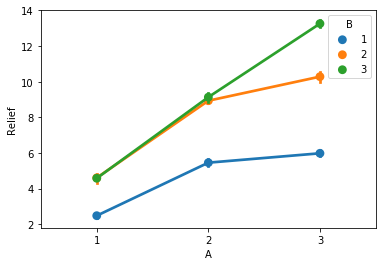

In [117]:
sns.pointplot(x='A', y='Relief', data=df1, hue='B')

### From the above plot, we can observe that 
### At Level 1 of B : there is a linear increase in hours of Relief from Level 1 of A to Level 2 of A and almost a constant number of hours from level 2 of A to Level 3 of A.
### At level 2 of B : there is a linear increase in hours of Relief from Level 1 of A to Level 2 of A and a very small increasing change in number of hours from level 2 of A to Level 3 of A.
### At level 3 of B : there is a linear increase in hours of Relief from each levels of A.

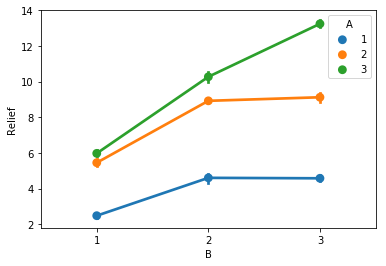

In [118]:
sns.pointplot(x='B', y='Relief', data=df1, hue='A')

### From the above plot, we can observe that 
### At level 1 of A : the number of hours of relief seems to be low for level 1 of B and high for level 2 and 3 of B
### At level 2 of A : the number of hours of relief seems to be low for level 1 of B and high for level 2 and 3 of B
### At level 3 of A : the number of hours of relief seems to be increasing as the level of B goes higher. With A at level 3, highest relief hours is seen with B at level 3

### 1.5) Perform a two-way ANOVA based on the different ingredients (variable ‘A’ & ‘B’) with the variable 'Relief' and state your results.

### Ans:

### Performing a two-way ANOVA based on variable 'A' and 'B' with variable 'Relief'

In [119]:
formula = 'Relief ~ C(A) + C(B)'
model = ols(formula, df1).fit()
aov_table = anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq           F        PR(>F)
C(A)       2.0  220.02  110.010000  109.832850  8.514029e-15
C(B)       2.0  123.66   61.830000   61.730435  1.546749e-11
Residual  31.0   31.05    1.001613         NaN           NaN


C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in greater
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in less
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:1821: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= self.a)


### From the above output, we can observe that:
### 1) For Variable 'A' , as the P Value is very low(8.514029e^-15) when compared to Alpha=0.05, the null hypothesis that the mean Relief Hours is same at different levels of 'A' is rejected.
### 2) For Variable 'B' , as the P Value is very low(1.546749e^-11) when compared to Alpha=0.05, the null hypothesis that the mean Relief Hours is same at different levels of 'B' is rejected.

### Performing a two-way ANOVA based on variable 'A' and 'B' and the interaction effect of variable 'A' and 'B' with variable 'Relief'

In [120]:
formula = 'Relief ~ C(A) + C(B) + C(A):C(B)'
model = ols(formula, df1).fit()
aov_table = anova_lm(model)
print(aov_table)

             df   sum_sq     mean_sq            F        PR(>F)
C(A)        2.0  220.020  110.010000  1827.858462  1.514043e-29
C(B)        2.0  123.660   61.830000  1027.329231  3.348751e-26
C(A):C(B)   4.0   29.425    7.356250   122.226923  6.972083e-17
Residual   27.0    1.625    0.060185          NaN           NaN


C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in greater
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in less
  return (self.a < x) & (x < self.b)
C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:1821: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= self.a)


### From the above output, we can observe that:
### 1) For Variable 'A' , as the P Value is very low(1.514043e^-29) when compared to Alpha=0.05, the null hypothesis that the mean Relief Hours is same at different levels of 'A' is rejected.
### 2) For Variable 'B' , as the P Value is very low(3.348751e^-26) when compared to Alpha=0.05, the null hypothesis that the mean Relief Hours is same at different levels of 'B' is rejected.
### 3) For the interaction of Variable 'A' and Variable 'B' , as the P Value is very low(6.972083e^-17) when compared to Alpha =0.05, the null hypothesis that there is no interaction between Variable 'A' and 'B' is rejected.

### 1.6) Mention the business implications of performing ANOVA for this particular case study.

### Ans:

### 1) The mean number of hours of Relief for Hay Fever is different for different levels of A.
### 2) The mean number of hours of Relief for Hay Fever is different for different levels of B.
### 3) For lower levels of A and B, the number of hours of Relief for Hay Fever is Low and for higher levels of A and B, the number of hours of Relief for Hay Fever is High.
### 4) There is significant interaction in the number of hours of Relief for Hay Fever between the different levels of A and B.
### 5) The most effective Relief for Hay Fever is seen when patients are given a compound with higher levels of Ingredients of A and B.

# Problem 2:

## The dataset Education - Post 12th Standard.csv is a dataset which contains the names of various colleges. This particular case study is based on various parameters of various institutions. You are expected to do Principal Component Analysis for this case study according to the instructions given in the following rubric. The data dictionary of the 'Education - Post 12th Standard.csv' can be found in the following file: Data Dictionary.xlsx.

### Loading the dataset

In [121]:
df2 = pd.read_csv('Education - Post 12th Standard-1.csv')

In [122]:
df2.head()

,Names,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### 2.1) Perform Exploratory Data Analysis [both univariate and multivariate analysis to be performed]. The inferences drawn from this should be properly documented.

### Ans:

In [123]:
df2.shape

(777, 18)

In [124]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
Names          777 non-null object
Apps           777 non-null int64
Accept         777 non-null int64
Enroll         777 non-null int64
Top10perc      777 non-null int64
Top25perc      777 non-null int64
F.Undergrad    777 non-null int64
P.Undergrad    777 non-null int64
Outstate       777 non-null int64
Room.Board     777 non-null int64
Books          777 non-null int64
Personal       777 non-null int64
PhD            777 non-null int64
Terminal       777 non-null int64
S.F.Ratio      777 non-null float64
perc.alumni    777 non-null int64
Expend         777 non-null int64
Grad.Rate      777 non-null int64
dtypes: float64(1), int64(16), object(1)
memory usage: 109.3+ KB


In [125]:
df2.describe(include='all')

,Names,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
unique,777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Sioux Falls College,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,NaN,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,NaN,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,NaN,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,NaN,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,NaN,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000


In [126]:
dups = df2.duplicated().sum()
dups

0

In [127]:
df2_a = df2[['Names','Accept','Enroll']]
df2_a['EnrollmentRate']=(df2_a['Enroll']/df2_a['Accept']*100)
df2_a[['Names','Accept','Enroll','EnrollmentRate']]

C:\Users\arigilasrinivas\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


,Names,Accept,Enroll,EnrollmentRate
0,Abilene Christian University,1232,721,58.522727
1,Adelphi University,1924,512,26.611227
2,Adrian College,1097,336,30.628988
3,Agnes Scott College,349,137,39.255014
4,Alaska Pacific University,146,55,37.671233
5,Albertson College,479,158,32.985386
6,Albertus Magnus College,340,103,30.294118
7,Albion College,1720,489,28.430233
8,Albright College,839,227,27.056019
9,Alderson-Broaddus College,498,172,34.538153


In [128]:
df2_a['EnrollmentRate'].nlargest(10)

77     100.000000
66      97.882736
376     93.827160
447     91.417166
275     86.524823
69      85.431322
142     83.544304
247     82.547170
645     81.268882
403     80.403458
Name: EnrollmentRate, dtype: float64

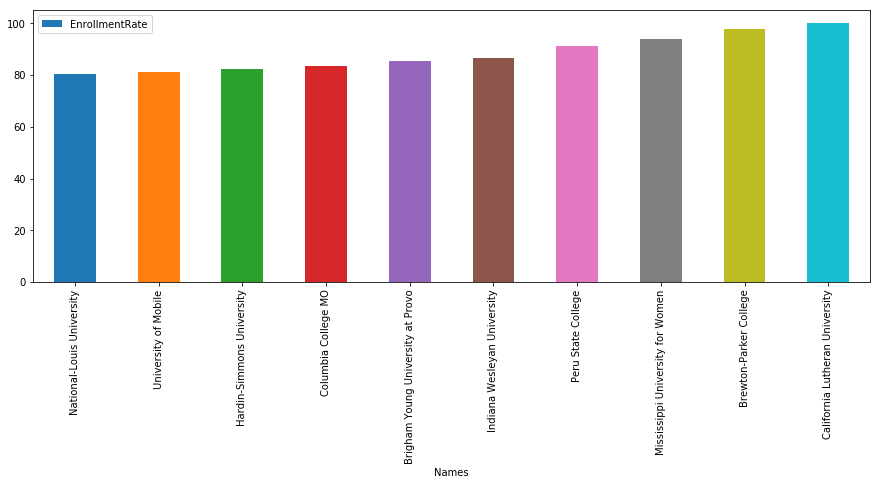

In [129]:
df2_a.groupby(by=['Names'])['EnrollmentRate'].sum().reset_index().sort_values(['EnrollmentRate']).tail(10).plot(x='Names',y='EnrollmentRate',kind='bar',figsize=(15,5))
plt.show()

In [130]:
df2[['Names','S.F.Ratio']][(df2['S.F.Ratio']==df2['S.F.Ratio'].min()) | (df2['S.F.Ratio']==df2['S.F.Ratio'].max())]

,Names,S.F.Ratio
275,Indiana Wesleyan University,39.8
608,University of Charleston,2.5


In [131]:
df2[['Names','Apps']][(df2['Apps']==df2['Apps'].min()) | (df2['Apps']==df2['Apps'].max())]

,Names,Apps
110,Christendom College,81
483,Rutgers at New Brunswick,48094


In [132]:
df2[['Names','Outstate']][(df2['Outstate']==df2['Outstate'].min()) | (df2['Outstate']==df2['Outstate'].max())]

,Names,Outstate
47,Bennington College,21700
69,Brigham Young University at Provo,2340


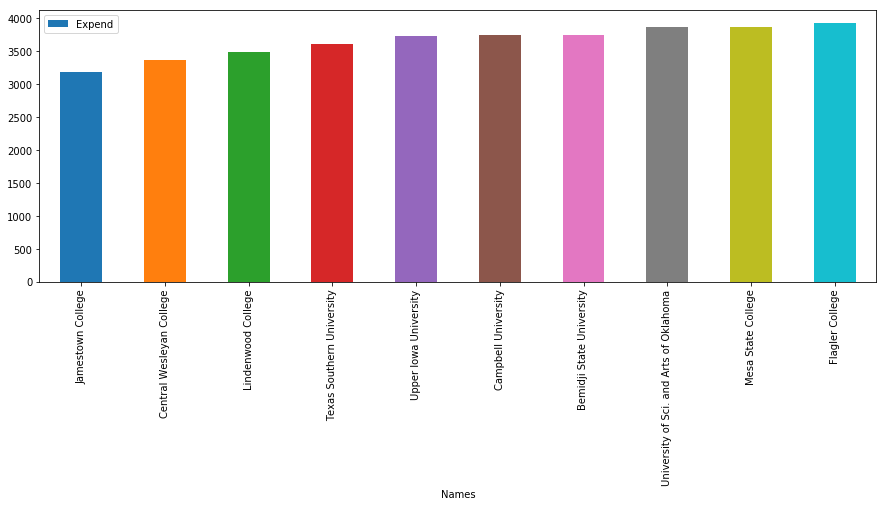

In [133]:
df2.groupby(by=['Names'])['Expend'].sum().reset_index().sort_values(['Expend']).head(10).plot(x='Names',y='Expend',kind='bar',figsize=(15,5))
plt.show()

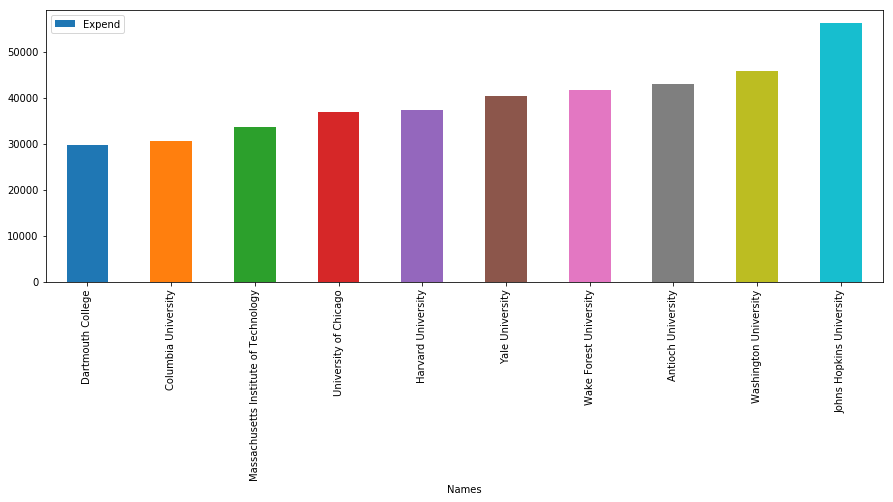

In [134]:
df2.groupby(by=['Names'])['Expend'].sum().reset_index().sort_values(['Expend']).tail(10).plot(x='Names',y='Expend',kind='bar',figsize=(15,5))
plt.show()

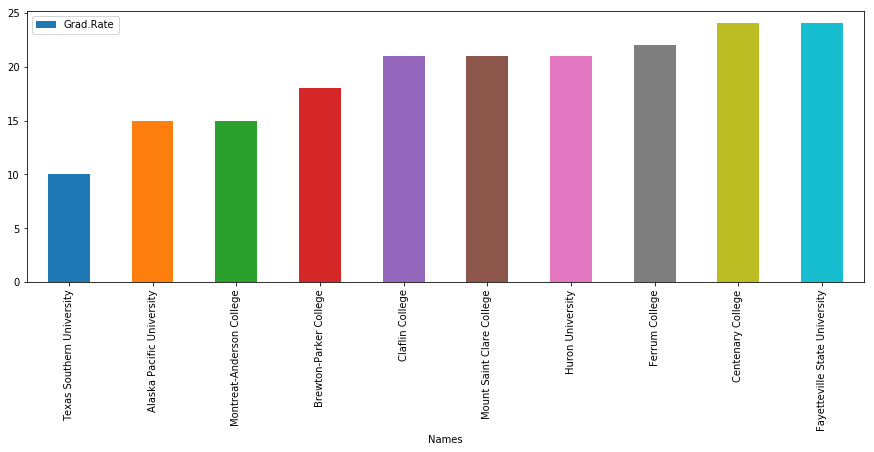

In [135]:
df2.groupby(by=['Names'])['Grad.Rate'].sum().reset_index().sort_values(['Grad.Rate']).head(10).plot(x='Names',y='Grad.Rate',kind='bar',figsize=(15,5))
plt.show()

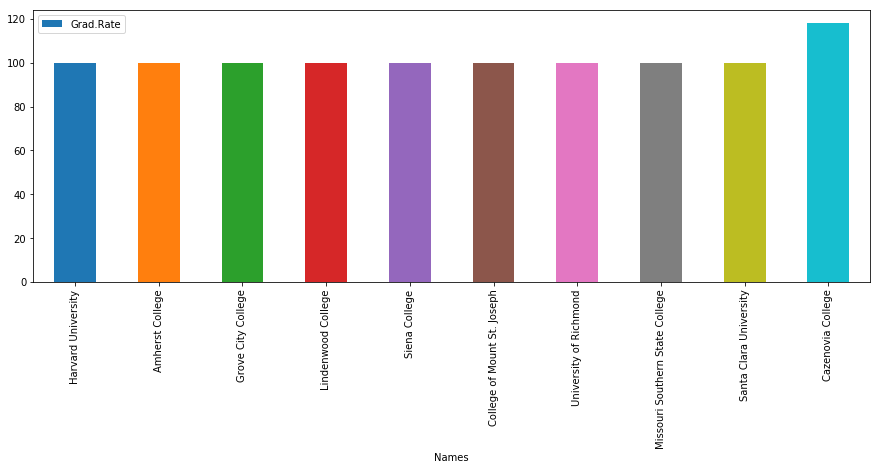

In [136]:
df2.groupby(by=['Names'])['Grad.Rate'].sum().reset_index().sort_values(['Grad.Rate']).tail(10).plot(x='Names',y='Grad.Rate',kind='bar',figsize=(15,5))
plt.show()

In [137]:
df2.isnull().sum()

Names          0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

In [138]:
df2.min()

Names          Abilene Christian University
Apps                                     81
Accept                                   72
Enroll                                   35
Top10perc                                 1
Top25perc                                 9
F.Undergrad                             139
P.Undergrad                               1
Outstate                               2340
Room.Board                             1780
Books                                    96
Personal                                250
PhD                                       8
Terminal                                 24
S.F.Ratio                               2.5
perc.alumni                               0
Expend                                 3186
Grad.Rate                                10
dtype: object

In [139]:
df2.max()

Names          York College of Pennsylvania
Apps                                  48094
Accept                                26330
Enroll                                 6392
Top10perc                                96
Top25perc                               100
F.Undergrad                           31643
P.Undergrad                           21836
Outstate                              21700
Room.Board                             8124
Books                                  2340
Personal                               6800
PhD                                     103
Terminal                                100
S.F.Ratio                              39.8
perc.alumni                              64
Expend                                56233
Grad.Rate                               118
dtype: object

### IQR

In [140]:
df2.quantile(0.75) - df2.quantile(0.25)

Apps           2848.0
Accept         1820.0
Enroll          660.0
Top10perc        20.0
Top25perc        28.0
F.Undergrad    3013.0
P.Undergrad     872.0
Outstate       5605.0
Room.Board     1453.0
Books           130.0
Personal        850.0
PhD              23.0
Terminal         21.0
S.F.Ratio         5.0
perc.alumni      18.0
Expend         4079.0
Grad.Rate        25.0
dtype: float64

### VARIANCE

In [141]:
df2.var()

Apps           1.497846e+07
Accept         6.007960e+06
Enroll         8.633684e+05
Top10perc      3.111825e+02
Top25perc      3.922292e+02
F.Undergrad    2.352658e+07
P.Undergrad    2.317799e+06
Outstate       1.618466e+07
Room.Board     1.202743e+06
Books          2.725978e+04
Personal       4.584258e+05
PhD            2.666086e+02
Terminal       2.167478e+02
S.F.Ratio      1.566853e+01
perc.alumni    1.535567e+02
Expend         2.726687e+07
Grad.Rate      2.950737e+02
dtype: float64

### SKEWNESS

In [142]:
df2.skew()

Apps           3.723750
Accept         3.417727
Enroll         2.690465
Top10perc      1.413217
Top25perc      0.259340
F.Undergrad    2.610458
P.Undergrad    5.692353
Outstate       0.509278
Room.Board     0.477356
Books          3.485025
Personal       1.742497
PhD           -0.768170
Terminal      -0.816542
S.F.Ratio      0.667435
perc.alumni    0.606891
Expend         3.459322
Grad.Rate     -0.113777
dtype: float64

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 <a list of 17 Text xticklabel objects>)

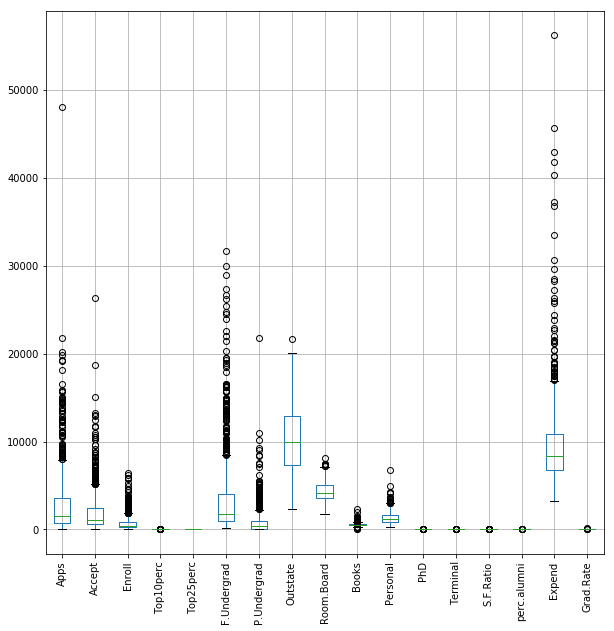

In [143]:
df2.boxplot(figsize=(10,10))
plt.xticks(rotation=90)

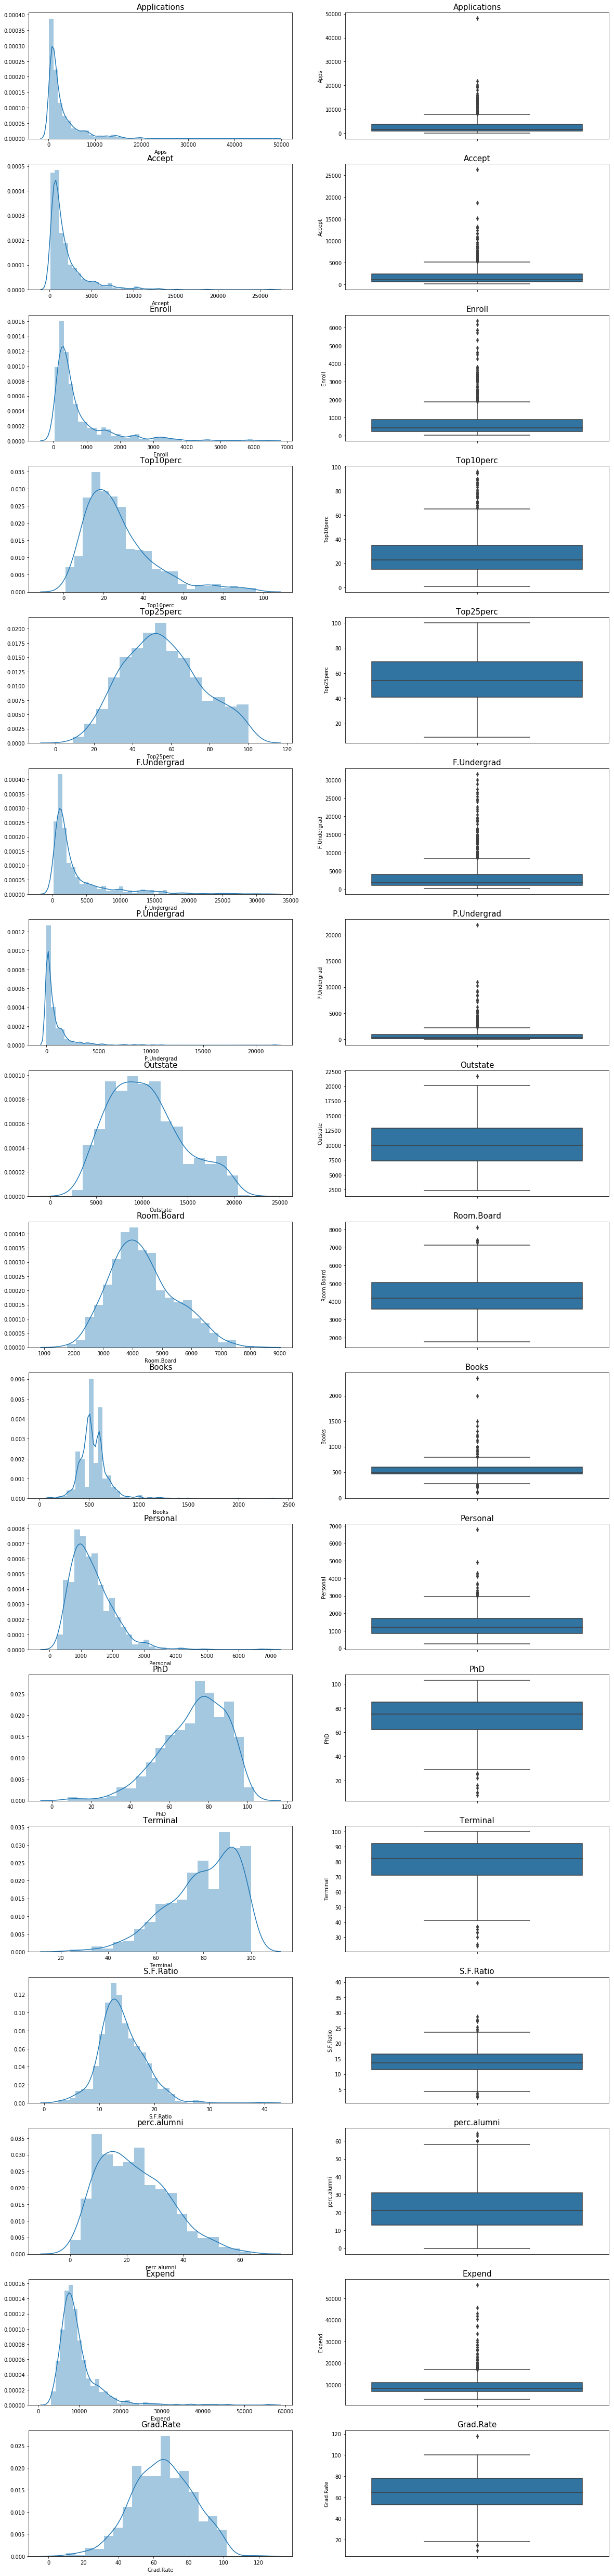

In [144]:
fig, axes = plt.subplots(nrows=17,ncols=2)
fig.set_size_inches(20, 90)

a = sns.distplot(df2['Apps'] , ax=axes[0][0])
a.set_title("Applications",fontsize=15)
a = sns.boxplot(df2['Apps'] , orient = "v" , ax=axes[0][1])
a.set_title("Applications",fontsize=15)

a = sns.distplot(df2['Accept'] , ax=axes[1][0])
a.set_title("Accept",fontsize=15)
a = sns.boxplot(df2['Accept'] , orient = "v" , ax=axes[1][1])
a.set_title("Accept",fontsize=15)

a = sns.distplot(df2['Enroll'] , ax=axes[2][0])
a.set_title("Enroll",fontsize=15)
a = sns.boxplot(df2['Enroll'] , orient = "v" , ax=axes[2][1])
a.set_title("Enroll",fontsize=15)

a = sns.distplot(df2['Top10perc'] , ax=axes[3][0])
a.set_title("Top10perc",fontsize=15)
a = sns.boxplot(df2['Top10perc'] , orient = "v" , ax=axes[3][1])
a.set_title("Top10perc",fontsize=15)

a = sns.distplot(df2['Top25perc'] , ax=axes[4][0])
a.set_title("Top25perc",fontsize=15)
a = sns.boxplot(df2['Top25perc'] , orient = "v" , ax=axes[4][1])
a.set_title("Top25perc",fontsize=15)

a = sns.distplot(df2['F.Undergrad'] , ax=axes[5][0])
a.set_title("F.Undergrad",fontsize=15)
a = sns.boxplot(df2['F.Undergrad'] , orient = "v" , ax=axes[5][1])
a.set_title("F.Undergrad",fontsize=15)

a = sns.distplot(df2['P.Undergrad'] , ax=axes[6][0])
a.set_title("P.Undergrad",fontsize=15)
a = sns.boxplot(df2['P.Undergrad'] , orient = "v" , ax=axes[6][1])
a.set_title("P.Undergrad",fontsize=15)

a = sns.distplot(df2['Outstate'] , ax=axes[7][0])
a.set_title("Outstate",fontsize=15)
a = sns.boxplot(df2['Outstate'] , orient = "v" , ax=axes[7][1])
a.set_title("Outstate",fontsize=15)

a = sns.distplot(df2['Room.Board'] , ax=axes[8][0])
a.set_title("Room.Board",fontsize=15)
a = sns.boxplot(df2['Room.Board'] , orient = "v" , ax=axes[8][1])
a.set_title("Room.Board",fontsize=15)

a = sns.distplot(df2['Books'] , ax=axes[9][0])
a.set_title("Books",fontsize=15)
a = sns.boxplot(df2['Books'] , orient = "v" , ax=axes[9][1])
a.set_title("Books",fontsize=15)

a = sns.distplot(df2['Personal'] , ax=axes[10][0])
a.set_title("Personal",fontsize=15)
a = sns.boxplot(df2['Personal'] , orient = "v" , ax=axes[10][1])
a.set_title("Personal",fontsize=15)

a = sns.distplot(df2['PhD'] , ax=axes[11][0])
a.set_title("PhD",fontsize=15)
a = sns.boxplot(df2['PhD'] , orient = "v" , ax=axes[11][1])
a.set_title("PhD",fontsize=15)

a = sns.distplot(df2['Terminal'] , ax=axes[12][0])
a.set_title("Terminal",fontsize=15)
a = sns.boxplot(df2['Terminal'] , orient = "v" , ax=axes[12][1])
a.set_title("Terminal",fontsize=15)

a = sns.distplot(df2['S.F.Ratio'] , ax=axes[13][0])
a.set_title("S.F.Ratio",fontsize=15)
a = sns.boxplot(df2['S.F.Ratio'] , orient = "v" , ax=axes[13][1])
a.set_title("S.F.Ratio",fontsize=15)

a = sns.distplot(df2['perc.alumni'] , ax=axes[14][0])
a.set_title("perc.alumni",fontsize=15)
a = sns.boxplot(df2['perc.alumni'] , orient = "v" , ax=axes[14][1])
a.set_title("perc.alumni",fontsize=15)

a = sns.distplot(df2['Expend'] , ax=axes[15][0])
a.set_title("Expend",fontsize=15)
a = sns.boxplot(df2['Expend'] , orient = "v" , ax=axes[15][1])
a.set_title("Expend",fontsize=15)

a = sns.distplot(df2['Grad.Rate'] , ax=axes[16][0])
a.set_title("Grad.Rate",fontsize=15)
a = sns.boxplot(df2['Grad.Rate'] , orient = "v" , ax=axes[16][1])
a.set_title("Grad.Rate",fontsize=15)

plt.show()

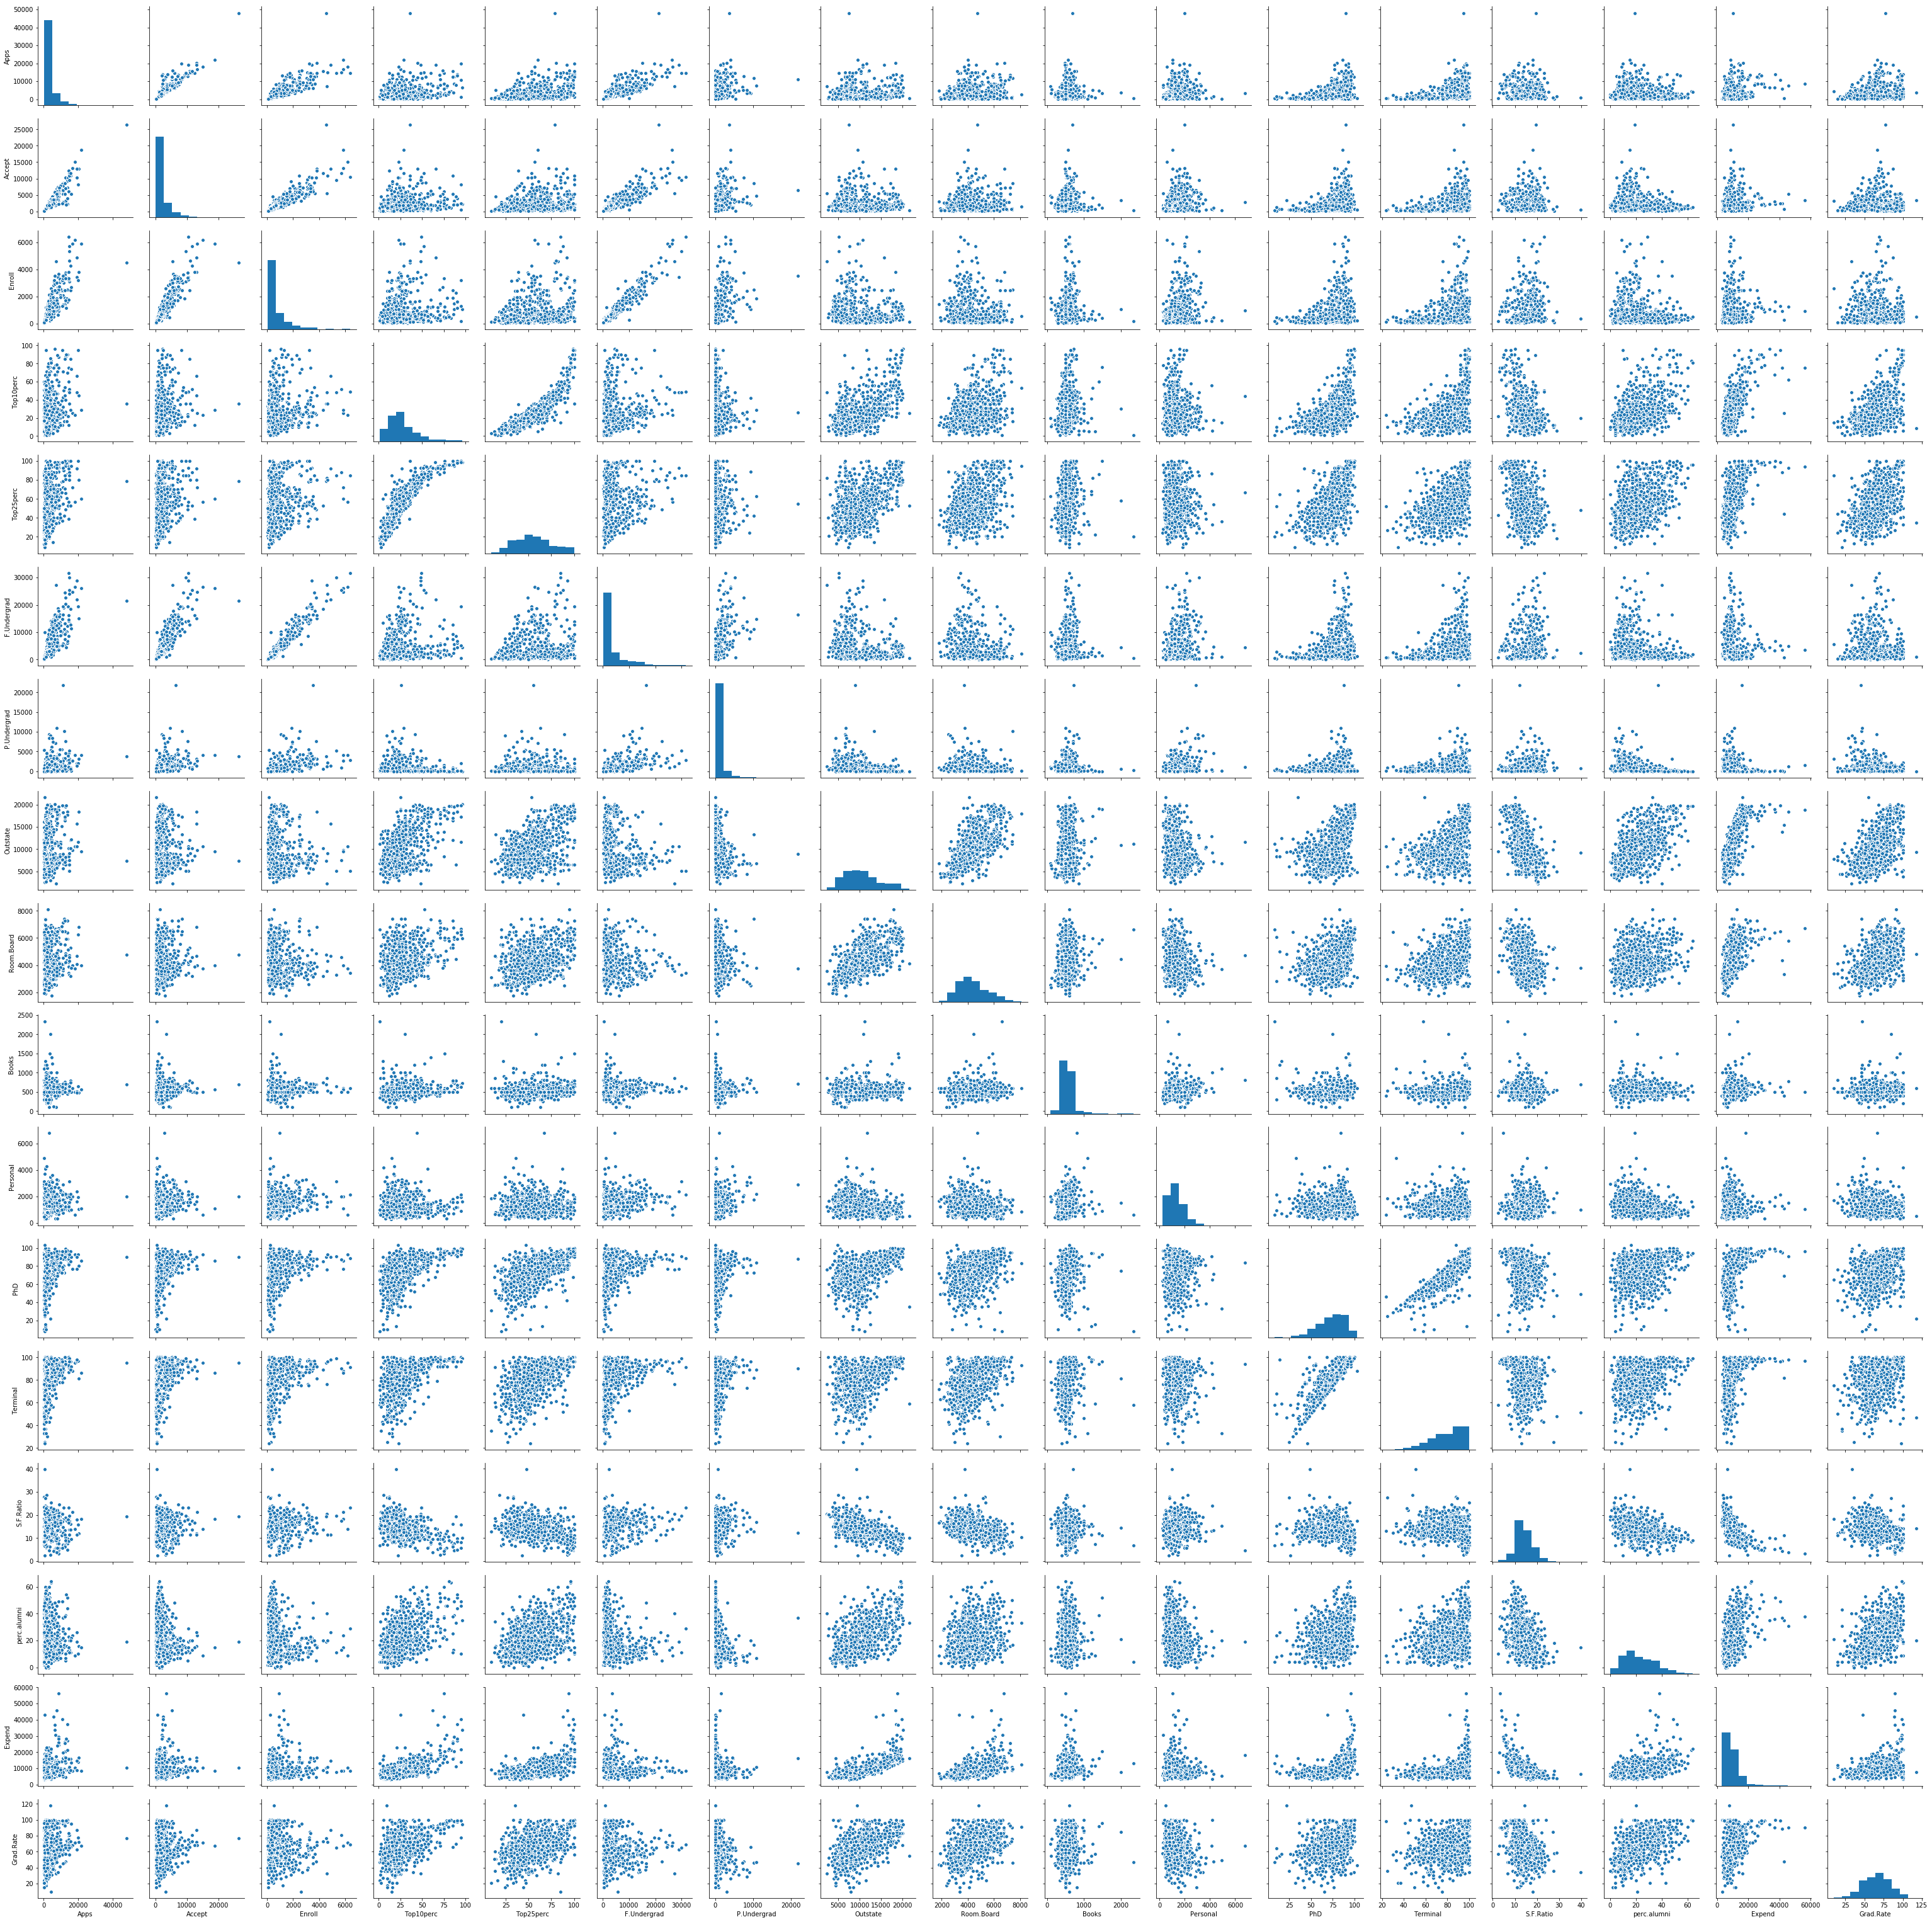

In [145]:
sns.pairplot(df2)

In [146]:
df2.cov()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Apps,1.497846e+07,8.949860e+06,3.045256e+06,23132.773138,26952.663479,1.528970e+07,2.346620e+06,7.809704e+05,7.000729e+05,84703.752639,4.683468e+05,24689.433666,21053.067602,1465.060576,-4327.122381,5.246171e+06,9756.421641
Accept,8.949860e+06,6.007960e+06,2.076268e+06,8321.124872,12013.404757,1.039358e+07,1.646670e+06,-2.539623e+05,2.443471e+05,45942.807867,3.335566e+05,14238.201489,12182.093828,1709.838189,-4859.487022,1.596272e+06,2834.162918
Enroll,3.045256e+06,2.076268e+06,8.633684e+05,2971.583415,4172.592435,4.347530e+06,7.257907e+05,-5.811885e+05,-4.099706e+04,17291.199742,1.767380e+05,5028.961166,4217.086027,872.684773,-2081.693787,3.113454e+05,-356.587977
Top10perc,2.313277e+04,8.321125e+03,2.971583e+03,311.182456,311.630480,1.208911e+04,-2.829475e+03,3.990718e+04,7.186706e+03,346.177405,-1.114551e+03,153.184870,127.551581,-26.874525,99.567208,6.087931e+04,149.992164
Top25perc,2.695266e+04,1.201340e+04,4.172592e+03,311.630480,392.229216,1.915895e+04,-1.615412e+03,3.899243e+04,7.199904e+03,377.759266,-1.083605e+03,176.518449,153.002612,-23.097199,102.550946,5.454648e+04,162.371398
F.Undergrad,1.528970e+07,1.039358e+07,4.347530e+06,12089.113681,19158.952782,2.352658e+07,4.212910e+06,-4.209843e+06,-3.664582e+05,92535.764728,1.041709e+06,25211.784197,21424.241746,5370.208581,-13791.929691,4.724040e+05,-6563.307527
P.Undergrad,2.346620e+06,1.646670e+06,7.257907e+05,-2829.474981,-1615.412144,4.212910e+06,2.317799e+06,-1.552704e+06,-1.023919e+05,20410.446674,3.297324e+05,3706.756219,3180.596615,1401.302563,-5297.337090,-6.643512e+05,-6721.062488
Outstate,7.809704e+05,-2.539623e+05,-5.811885e+05,39907.179832,38992.427500,-4.209843e+06,-1.552704e+06,1.618466e+07,2.886597e+06,25808.242145,-8.146737e+05,25157.515051,24164.147673,-8835.253539,28229.553066,1.413324e+07,39479.681796
Room.Board,7.000729e+05,2.443471e+05,-4.099706e+04,7186.705605,7199.903568,-3.664582e+05,-1.023919e+05,2.886597e+06,1.202743e+06,23170.313390,-1.480838e+05,5895.034749,6047.299735,-1574.205914,3701.431379,2.873308e+06,8005.360183
Books,8.470375e+04,4.594281e+04,1.729120e+04,346.177405,377.759266,9.253576e+04,2.041045e+04,2.580824e+04,2.317031e+04,27259.779946,2.004303e+04,72.534242,242.963918,-20.867207,-82.263132,9.691258e+04,3.008837


In [147]:
df2.corr()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Apps,1.000000,0.943451,0.846822,0.338834,0.351640,0.814491,0.398264,0.050159,0.164939,0.132559,0.178731,0.390697,0.369491,0.095633,-0.090226,0.259592,0.146755
Accept,0.943451,1.000000,0.911637,0.192447,0.247476,0.874223,0.441271,-0.025755,0.090899,0.113525,0.200989,0.355758,0.337583,0.176229,-0.159990,0.124717,0.067313
Enroll,0.846822,0.911637,1.000000,0.181294,0.226745,0.964640,0.513069,-0.155477,-0.040232,0.112711,0.280929,0.331469,0.308274,0.237271,-0.180794,0.064169,-0.022341
Top10perc,0.338834,0.192447,0.181294,1.000000,0.891995,0.141289,-0.105356,0.562331,0.371480,0.118858,-0.093316,0.531828,0.491135,-0.384875,0.455485,0.660913,0.494989
Top25perc,0.351640,0.247476,0.226745,0.891995,1.000000,0.199445,-0.053577,0.489394,0.331490,0.115527,-0.080810,0.545862,0.524749,-0.294629,0.417864,0.527447,0.477281
F.Undergrad,0.814491,0.874223,0.964640,0.141289,0.199445,1.000000,0.570512,-0.215742,-0.068890,0.115550,0.317200,0.318337,0.300019,0.279703,-0.229462,0.018652,-0.078773
P.Undergrad,0.398264,0.441271,0.513069,-0.105356,-0.053577,0.570512,1.000000,-0.253512,-0.061326,0.081200,0.319882,0.149114,0.141904,0.232531,-0.280792,-0.083568,-0.257001
Outstate,0.050159,-0.025755,-0.155477,0.562331,0.489394,-0.215742,-0.253512,1.000000,0.654256,0.038855,-0.299087,0.382982,0.407983,-0.554821,0.566262,0.672779,0.571290
Room.Board,0.164939,0.090899,-0.040232,0.371480,0.331490,-0.068890,-0.061326,0.654256,1.000000,0.127963,-0.199428,0.329202,0.374540,-0.362628,0.272363,0.501739,0.424942
Books,0.132559,0.113525,0.112711,0.118858,0.115527,0.115550,0.081200,0.038855,0.127963,1.000000,0.179295,0.026906,0.099955,-0.031929,-0.040208,0.112409,0.001061


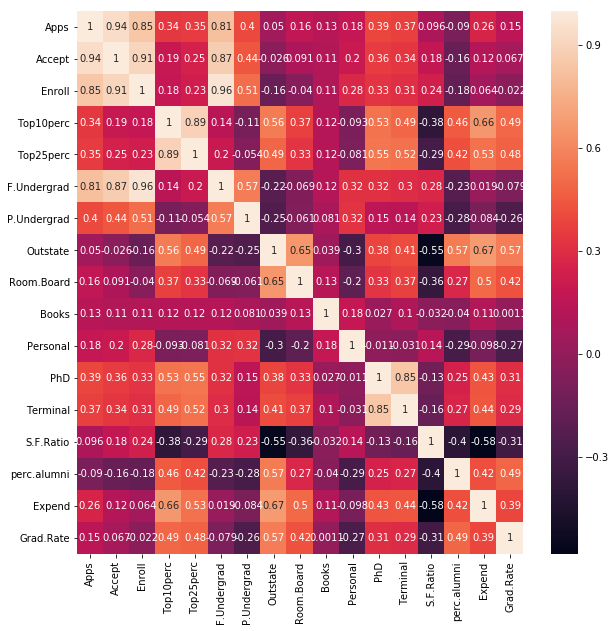

In [148]:
plt.figure(figsize=(10,10))
sns.heatmap(df2.corr(), annot = True)

### 2.2) Scale the variables and write the inference for using the type of scaling function for this case study.

### Ans:

In [149]:
df2_new = df2.drop(['Names'], axis = 1)
df2_new.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [150]:
df2_new.shape

(777, 17)

In [151]:
df2_new_without_treating_outliers = df2_new

In [152]:
from scipy.stats import zscore
df2_new_without_treating_outliers=df2_new_without_treating_outliers.apply(zscore)
df2_new_without_treating_outliers.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,-0.346882,-0.321205,-0.063509,-0.258583,-0.191827,-0.168116,-0.209207,-0.746356,-0.964905,-0.602312,1.270045,-0.163028,-0.115729,1.013776,-0.867574,-0.501910,-0.318252
1,-0.210884,-0.038703,-0.288584,-0.655656,-1.353911,-0.209788,0.244307,0.457496,1.909208,1.215880,0.235515,-2.675646,-3.378176,-0.477704,-0.544572,0.166110,-0.551262
2,-0.406866,-0.376318,-0.478121,-0.315307,-0.292878,-0.549565,-0.497090,0.201305,-0.554317,-0.905344,-0.259582,-1.204845,-0.931341,-0.300749,0.585935,-0.177290,-0.667767
3,-0.668261,-0.681682,-0.692427,1.840231,1.677612,-0.658079,-0.520752,0.626633,0.996791,-0.602312,-0.688173,1.185206,1.175657,-1.615274,1.151188,1.792851,-0.376504
4,-0.726176,-0.764555,-0.780735,-0.655656,-0.596031,-0.711924,0.009005,-0.716508,-0.216723,1.518912,0.235515,0.204672,-0.523535,-0.553542,-1.675079,0.241803,-2.939613


In [153]:
df2_new_without_treating_outliers.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02,7.770000e+02
mean,6.355797e-17,6.774575e-17,-5.249269e-17,-2.753232e-17,-1.546739e-16,-1.661405e-16,-3.029180e-17,6.515595e-17,3.570717e-16,-2.192583e-16,4.765243e-17,5.954768e-17,-4.481615e-16,-2.057556e-17,-6.022638e-17,1.213101e-16,3.886495e-16
std,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00,1.000644e+00
min,-7.551337e-01,-7.947645e-01,-8.022728e-01,-1.506526e+00,-2.364419e+00,-7.346169e-01,-5.615022e-01,-2.014878e+00,-2.351778e+00,-2.747779e+00,-1.611860e+00,-3.962596e+00,-3.785982e+00,-2.929799e+00,-1.836580e+00,-1.240641e+00,-3.230876e+00
25%,-5.754408e-01,-5.775805e-01,-5.793514e-01,-7.123803e-01,-7.476067e-01,-5.586426e-01,-4.997191e-01,-7.762035e-01,-6.939170e-01,-4.810994e-01,-7.251203e-01,-6.532948e-01,-5.915023e-01,-6.546598e-01,-7.868237e-01,-5.574826e-01,-7.260193e-01
50%,-3.732540e-01,-3.710108e-01,-3.725836e-01,-2.585828e-01,-9.077663e-02,-4.111378e-01,-3.301442e-01,-1.120949e-01,-1.437297e-01,-2.992802e-01,-2.078552e-01,1.433889e-01,1.561419e-01,-1.237939e-01,-1.408197e-01,-2.458933e-01,-2.698956e-02
75%,1.609122e-01,1.654173e-01,1.314128e-01,4.221134e-01,6.671042e-01,6.294077e-02,7.341765e-02,6.179271e-01,6.318245e-01,3.067838e-01,5.310950e-01,7.562224e-01,8.358184e-01,6.093067e-01,6.666852e-01,2.241735e-01,7.302926e-01
max,1.165867e+01,9.924816e+00,6.043678e+00,3.882319e+00,2.233391e+00,5.764674e+00,1.378992e+01,2.800531e+00,3.436593e+00,1.085230e+01,8.068387e+00,1.859323e+00,1.379560e+00,6.499390e+00,3.331452e+00,8.924721e+00,3.060392e+00


In [154]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [155]:
lower,upper=remove_outlier(df2_new['Apps'])
df2_new['Apps']=np.where(df2_new['Apps']>upper,upper,df2_new['Apps'])
df2_new['Apps']=np.where(df2_new['Apps']<lower,lower,df2_new['Apps'])

lower,upper=remove_outlier(df2_new['Accept'])
df2_new['Accept']=np.where(df2_new['Accept']>upper,upper,df2_new['Accept'])
df2_new['Accept']=np.where(df2_new['Accept']<lower,lower,df2_new['Accept'])

lower,upper=remove_outlier(df2_new['Enroll'])
df2_new['Enroll']=np.where(df2_new['Enroll']>upper,upper,df2_new['Enroll'])
df2_new['Enroll']=np.where(df2_new['Enroll']<lower,lower,df2_new['Enroll'])

lower,upper=remove_outlier(df2_new['Top10perc'])
df2_new['Top10perc']=np.where(df2_new['Top10perc']>upper,upper,df2_new['Top10perc'])
df2_new['Top10perc']=np.where(df2_new['Top10perc']<lower,lower,df2_new['Top10perc'])

lower,upper=remove_outlier(df2_new['F.Undergrad'])
df2_new['F.Undergrad']=np.where(df2_new['F.Undergrad']>upper,upper,df2_new['F.Undergrad'])
df2_new['F.Undergrad']=np.where(df2_new['F.Undergrad']<lower,lower,df2_new['F.Undergrad'])

lower,upper=remove_outlier(df2_new['P.Undergrad'])
df2_new['P.Undergrad']=np.where(df2_new['P.Undergrad']>upper,upper,df2_new['P.Undergrad'])
df2_new['P.Undergrad']=np.where(df2_new['P.Undergrad']<lower,lower,df2_new['P.Undergrad'])

lower,upper=remove_outlier(df2_new['Outstate'])
df2_new['Outstate']=np.where(df2_new['Outstate']>upper,upper,df2_new['Outstate'])
df2_new['Outstate']=np.where(df2_new['Outstate']<lower,lower,df2_new['Outstate'])

lower,upper=remove_outlier(df2_new['Room.Board'])
df2_new['Room.Board']=np.where(df2_new['Room.Board']>upper,upper,df2_new['Room.Board'])
df2_new['Room.Board']=np.where(df2_new['Room.Board']<lower,lower,df2_new['Room.Board'])

lower,upper=remove_outlier(df2_new['Books'])
df2_new['Books']=np.where(df2_new['Books']>upper,upper,df2_new['Books'])
df2_new['Books']=np.where(df2_new['Books']<lower,lower,df2_new['Books'])

lower,upper=remove_outlier(df2_new['Personal'])
df2_new['Personal']=np.where(df2_new['Personal']>upper,upper,df2_new['Personal'])
df2_new['Personal']=np.where(df2_new['Personal']<lower,lower,df2_new['Personal'])

lower,upper=remove_outlier(df2_new['PhD'])
df2_new['PhD']=np.where(df2_new['PhD']>upper,upper,df2_new['PhD'])
df2_new['PhD']=np.where(df2_new['PhD']<lower,lower,df2_new['PhD'])

lower,upper=remove_outlier(df2_new['Terminal'])
df2_new['Terminal']=np.where(df2_new['Terminal']>upper,upper,df2_new['Terminal'])
df2_new['Terminal']=np.where(df2_new['Terminal']<lower,lower,df2_new['Terminal'])

lower,upper=remove_outlier(df2_new['S.F.Ratio'])
df2_new['S.F.Ratio']=np.where(df2_new['S.F.Ratio']>upper,upper,df2_new['S.F.Ratio'])
df2_new['S.F.Ratio']=np.where(df2_new['S.F.Ratio']<lower,lower,df2_new['S.F.Ratio'])

lower,upper=remove_outlier(df2_new['perc.alumni'])
df2_new['perc.alumni']=np.where(df2_new['perc.alumni']>upper,upper,df2_new['perc.alumni'])
df2_new['perc.alumni']=np.where(df2_new['perc.alumni']<lower,lower,df2_new['perc.alumni'])

lower,upper=remove_outlier(df2_new['Expend'])
df2_new['Expend']=np.where(df2_new['Expend']>upper,upper,df2_new['Expend'])
df2_new['Expend']=np.where(df2_new['Expend']<lower,lower,df2_new['Expend'])

lower,upper=remove_outlier(df2_new['Grad.Rate'])
df2_new['Grad.Rate']=np.where(df2_new['Grad.Rate']>upper,upper,df2_new['Grad.Rate'])
df2_new['Grad.Rate']=np.where(df2_new['Grad.Rate']<lower,lower,df2_new['Grad.Rate'])

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 <a list of 17 Text xticklabel objects>)

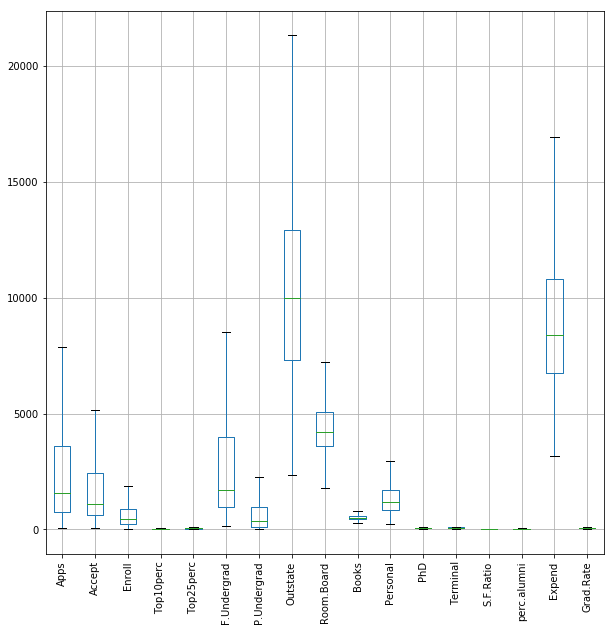

In [156]:
plt.figure(figsize=(10,10))
df2_new.boxplot()
plt.xticks(rotation=90)

In [157]:
df2_before_scaling = df2_new

In [158]:
from scipy.stats import zscore
df2_new=df2_new.apply(zscore)
df2_new.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,-0.376493,-0.337830,0.106380,-0.246780,-0.191827,-0.018769,-0.166083,-0.746480,-0.968324,-0.776567,1.438500,-0.174045,-0.123239,1.070602,-0.870466,-0.630916,-0.319205
1,-0.159195,0.116744,-0.260441,-0.696290,-1.353911,-0.093626,0.797856,0.457762,1.921680,1.828605,0.289289,-2.745731,-2.785068,-0.489511,-0.545726,0.396097,-0.552693
2,-0.472336,-0.426511,-0.569343,-0.310996,-0.292878,-0.703966,-0.777974,0.201488,-0.555466,-1.210762,-0.260691,-1.240354,-0.952900,-0.304413,0.590864,-0.131845,-0.669437
3,-0.889994,-0.917871,-0.918613,2.129202,1.677612,-0.898889,-0.828267,0.626954,1.004218,-0.776567,-0.736792,1.205884,1.190391,-1.679429,1.159159,2.287940,-0.377577
4,-0.982532,-1.051221,-1.062533,-0.696290,-0.596031,-0.995610,0.297726,-0.716623,-0.216006,2.219381,0.289289,0.202299,-0.538069,-0.568839,-1.682316,0.512468,-2.916759


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 <a list of 17 Text xticklabel objects>)

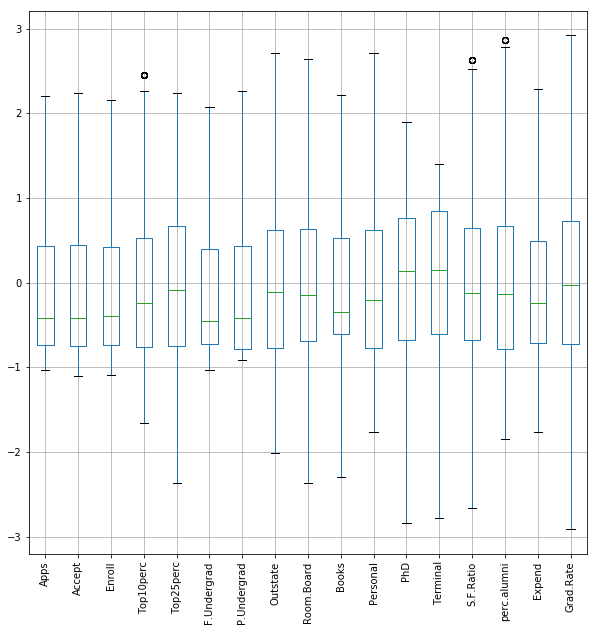

In [159]:
plt.figure(figsize=(10,10))
df2_new.boxplot()
plt.xticks(rotation=90)

### The goal of normalization is to transform features to be on a similar scale. This improves the performance and training stability of the model.
### Z-score is a variation of scaling that represents the number of standard deviations away from the mean. 
### We would use z-score to ensure that feature distributions have mean = 0 and std = 1. 
### Standardizing the features so that they are centered around 0 with a standard deviation of 1 is important if we are comparing measurements that have different units.
### Hence, in this case study we are using Z scaling technique for scaling the variables.

### 2.3) Comment on the comparison between covariance and the correlation matrix.

### Ans: 
### Covariance and Correlation Matrix on the dataset without treating outliers

In [160]:
cov_matrix = np.cov(df2_new_without_treating_outliers.T)
cov_matrix = pd.DataFrame(cov_matrix)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s           0         1         2         3         4         5         6   \
0   1.001289  0.944666  0.847913  0.339270  0.352093  0.815540  0.398777   
1   0.944666  1.001289  0.912811  0.192695  0.247795  0.875350  0.441839   
2   0.847913  0.912811  1.001289  0.181527  0.227037  0.965883  0.513730   
3   0.339270  0.192695  0.181527  1.001289  0.893144  0.141471 -0.105492   
4   0.352093  0.247795  0.227037  0.893144  1.001289  0.199702 -0.053646   
5   0.815540  0.875350  0.965883  0.141471  0.199702  1.001289  0.571247   
6   0.398777  0.441839  0.513730 -0.105492 -0.053646  0.571247  1.001289   
7   0.050224 -0.025788 -0.155678  0.563055  0.490024 -0.216020 -0.253839   
8   0.165152  0.091016 -0.040284  0.371959  0.331917 -0.068979 -0.061405   
9   0.132729  0.113672  0.112856  0.119012  0.115676  0.115699  0.081304   
10  0.178961  0.201248  0.281291 -0.093437 -0.080914  0.317608  0.320294   
11  0.391201  0.356216  0.331896  0.532513  0.546566  0.318747  0.

In [161]:
cor_matrix = df2_new_without_treating_outliers.corr()
cor_matrix = pd.DataFrame(cor_matrix)
print('Correlation Matrix \n%s', cor_matrix)

Correlation Matrix 
%s                  Apps    Accept    Enroll  Top10perc  Top25perc  F.Undergrad  \
Apps         1.000000  0.943451  0.846822   0.338834   0.351640     0.814491   
Accept       0.943451  1.000000  0.911637   0.192447   0.247476     0.874223   
Enroll       0.846822  0.911637  1.000000   0.181294   0.226745     0.964640   
Top10perc    0.338834  0.192447  0.181294   1.000000   0.891995     0.141289   
Top25perc    0.351640  0.247476  0.226745   0.891995   1.000000     0.199445   
F.Undergrad  0.814491  0.874223  0.964640   0.141289   0.199445     1.000000   
P.Undergrad  0.398264  0.441271  0.513069  -0.105356  -0.053577     0.570512   
Outstate     0.050159 -0.025755 -0.155477   0.562331   0.489394    -0.215742   
Room.Board   0.164939  0.090899 -0.040232   0.371480   0.331490    -0.068890   
Books        0.132559  0.113525  0.112711   0.118858   0.115527     0.115550   
Personal     0.178731  0.200989  0.280929  -0.093316  -0.080810     0.317200   
PhD          0.39

### Covariance and Correlation Matrix on the dataset after treating Outliers

In [162]:
cov_matrix = np.cov(df2_new.T)
cov_matrix = pd.DataFrame(cov_matrix)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s           0         1         2         3         4         5         6   \
0   1.001289  0.956538  0.898039  0.321756  0.364961  0.862111  0.520493   
1   0.956538  1.001289  0.936482  0.223586  0.274033  0.898190  0.573429   
2   0.898039  0.936482  1.001289  0.171977  0.230731  0.968549  0.642422   
3   0.321756  0.223586  0.171977  1.001289  0.915053  0.111358 -0.180241   
4   0.364961  0.274033  0.230731  0.915053  1.001289  0.181429 -0.099423   
5   0.862111  0.898190  0.968549  0.111358  0.181429  1.001289  0.697027   
6   0.520493  0.573429  0.642422 -0.180241 -0.099423  0.697027  1.001289   
7   0.065421 -0.005009 -0.155856  0.562884  0.490200 -0.226457 -0.354673   
8   0.187717  0.119740 -0.023876  0.357826  0.331413 -0.054546 -0.067725   
9   0.236442  0.208974  0.202317  0.153650  0.169980  0.208147  0.122686   
10  0.230244  0.256676  0.339785 -0.116880 -0.086922  0.360246  0.344496   
11  0.464522  0.427891  0.382031  0.544749  0.552172  0.362030  0.

In [163]:
cor_matrix = df2_new.corr()
cor_matrix = pd.DataFrame(cor_matrix)
print('Correlation Matrix \n%s', cor_matrix)

Correlation Matrix 
%s                  Apps    Accept    Enroll  Top10perc  Top25perc  F.Undergrad  \
Apps         1.000000  0.955307  0.896883   0.321342   0.364491     0.861002   
Accept       0.955307  1.000000  0.935277   0.223298   0.273681     0.897034   
Enroll       0.896883  0.935277  1.000000   0.171756   0.230434     0.967302   
Top10perc    0.321342  0.223298  0.171756   1.000000   0.913875     0.111215   
Top25perc    0.364491  0.273681  0.230434   0.913875   1.000000     0.181196   
F.Undergrad  0.861002  0.897034  0.967302   0.111215   0.181196     1.000000   
P.Undergrad  0.519823  0.572691  0.641595  -0.180009  -0.099295     0.696130   
Outstate     0.065337 -0.005002 -0.155655   0.562160   0.489569    -0.226166   
Room.Board   0.187475  0.119586 -0.023846   0.357366   0.330987    -0.054476   
Books        0.236138  0.208705  0.202057   0.153452   0.169761     0.207879   
Personal     0.229948  0.256346  0.339348  -0.116730  -0.086810     0.359783   
PhD          0.46

### As we can see from above output, the Covariance and the Correlation Matrix have similar values as these are performed after scaling the data.

### 2.4) Check the dataset for outliers before and after scaling. Draw your inferences from this exercise.

### Ans:

### Checking dataset for outliers without treating outliers and before scaling

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 <a list of 17 Text xticklabel objects>)

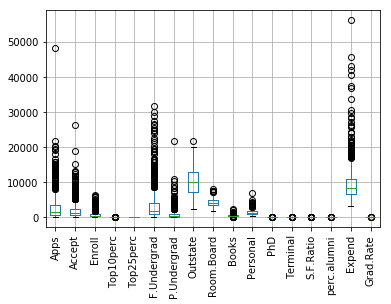

In [164]:
df2_before_scaling_1 = df2.drop(['Names'], axis = 1)
df2_before_scaling_1.boxplot()
plt.xticks(rotation=90)

### Checking dataset for outliers without treating outliers and after scaling

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 <a list of 17 Text xticklabel objects>)

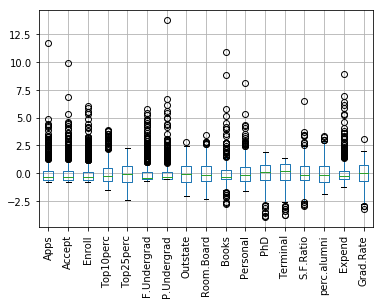

In [165]:
df2_after_scaling_1 = df2_new_without_treating_outliers
df2_after_scaling_1.boxplot()
plt.xticks(rotation=90)

In [166]:
lower, upper = remove_outlier(df2_before_scaling_1['Apps'])
print('Number of Outliers in Variable Apps before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Apps']< lower) | (df2_before_scaling_1['Apps'] > upper)]['Apps'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Apps'])
print('Number of Outliers in Variable Apps after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Apps']< lower) | (df2_after_scaling_1['Apps'] > upper)]['Apps'].count())

Number of Outliers in Variable Apps before scaling
70
Number of Outliers in Variable Apps after scaling
70


In [167]:
lower, upper = remove_outlier(df2_before_scaling_1['Accept'])
print('Number of Outliers in Variable Accept before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Accept']< lower) | (df2_before_scaling_1['Accept'] > upper)]['Accept'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Accept'])
print('Number of Outliers in Variable Accept after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Accept']< lower) | (df2_after_scaling_1['Accept'] > upper)]['Accept'].count())

Number of Outliers in Variable Accept before scaling
73
Number of Outliers in Variable Accept after scaling
73


In [168]:
lower, upper = remove_outlier(df2_before_scaling_1['Enroll'])
print('Number of Outliers in Variable Enroll before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Enroll']< lower) | (df2_before_scaling_1['Enroll'] > upper)]['Enroll'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Enroll'])
print('Number of Outliers in Variable Enroll after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Enroll']< lower) | (df2_after_scaling_1['Enroll'] > upper)]['Enroll'].count())

Number of Outliers in Variable Enroll before scaling
79
Number of Outliers in Variable Enroll after scaling
79


In [169]:
lower, upper = remove_outlier(df2_before_scaling_1['Top10perc'])
print('Number of Outliers in Variable Top10perc before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Top10perc']< lower) | (df2_before_scaling_1['Top10perc'] > upper)]['Top10perc'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Top10perc'])
print('Number of Outliers in Variable Top10perc after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Top10perc']< lower) | (df2_after_scaling_1['Top10perc'] > upper)]['Top10perc'].count())

Number of Outliers in Variable Top10perc before scaling
39
Number of Outliers in Variable Top10perc after scaling
39


In [170]:
lower, upper = remove_outlier(df2_before_scaling_1['Top25perc'])
print('Number of Outliers in Variable Top25perc before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Top25perc']< lower) | (df2_before_scaling_1['Top25perc'] > upper)]['Top25perc'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Top25perc'])
print('Number of Outliers in Variable Top25perc after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Top25perc']< lower) | (df2_after_scaling_1['Top25perc'] > upper)]['Top25perc'].count())

Number of Outliers in Variable Top25perc before scaling
0
Number of Outliers in Variable Top25perc after scaling
0


In [171]:
lower, upper = remove_outlier(df2_before_scaling_1['F.Undergrad'])
print('Number of Outliers in Variable F.Undergrad before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['F.Undergrad']< lower) | (df2_before_scaling_1['F.Undergrad'] > upper)]['F.Undergrad'].count())
lower, upper = remove_outlier(df2_after_scaling_1['F.Undergrad'])
print('Number of Outliers in Variable F.Undergrad after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['F.Undergrad']< lower) | (df2_after_scaling_1['F.Undergrad'] > upper)]['F.Undergrad'].count())

Number of Outliers in Variable F.Undergrad before scaling
97
Number of Outliers in Variable F.Undergrad after scaling
97


In [172]:
lower, upper = remove_outlier(df2_before_scaling_1['P.Undergrad'])
print('Number of Outliers in Variable P.Undergrad before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['P.Undergrad']< lower) | (df2_before_scaling_1['P.Undergrad'] > upper)]['P.Undergrad'].count())
lower, upper = remove_outlier(df2_after_scaling_1['P.Undergrad'])
print('Number of Outliers in Variable P.Undergrad after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['P.Undergrad']< lower) | (df2_after_scaling_1['P.Undergrad'] > upper)]['P.Undergrad'].count())

Number of Outliers in Variable P.Undergrad before scaling
67
Number of Outliers in Variable P.Undergrad after scaling
67


In [173]:
lower, upper = remove_outlier(df2_before_scaling_1['Outstate'])
print('Number of Outliers in Variable Outstate before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Outstate']< lower) | (df2_before_scaling_1['Outstate'] > upper)]['Outstate'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Outstate'])
print('Number of Outliers in Variable Outstate after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Outstate']< lower) | (df2_after_scaling_1['Outstate'] > upper)]['Outstate'].count())

Number of Outliers in Variable Outstate before scaling
1
Number of Outliers in Variable Outstate after scaling
1


In [174]:
lower, upper = remove_outlier(df2_before_scaling_1['Room.Board'])
print('Number of Outliers in Variable Room.Board before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Room.Board']< lower) | (df2_before_scaling_1['Room.Board'] > upper)]['Room.Board'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Room.Board'])
print('Number of Outliers in Variable Room.Board after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Room.Board']< lower) | (df2_after_scaling_1['Room.Board'] > upper)]['Room.Board'].count())

Number of Outliers in Variable Room.Board before scaling
7
Number of Outliers in Variable Room.Board after scaling
7


In [175]:
lower, upper = remove_outlier(df2_before_scaling_1['Books'])
print('Number of Outliers in Variable Books before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Books']< lower) | (df2_before_scaling_1['Books'] > upper)]['Books'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Books'])
print('Number of Outliers in Variable Books after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Books']< lower) | (df2_after_scaling_1['Books'] > upper)]['Books'].count())

Number of Outliers in Variable Books before scaling
46
Number of Outliers in Variable Books after scaling
48


In [176]:
lower, upper = remove_outlier(df2_before_scaling_1['Personal'])
print('Number of Outliers in Variable Personal before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Personal']< lower) | (df2_before_scaling_1['Personal'] > upper)]['Personal'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Personal'])
print('Number of Outliers in Variable Personal after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Personal']< lower) | (df2_after_scaling_1['Personal'] > upper)]['Personal'].count())

Number of Outliers in Variable Personal before scaling
20
Number of Outliers in Variable Personal after scaling
20


In [177]:
lower, upper = remove_outlier(df2_before_scaling_1['PhD'])
print('Number of Outliers in Variable PhD before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['PhD']< lower) | (df2_before_scaling_1['PhD'] > upper)]['PhD'].count())
lower, upper = remove_outlier(df2_after_scaling_1['PhD'])
print('Number of Outliers in Variable PhD after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['PhD']< lower) | (df2_after_scaling_1['PhD'] > upper)]['PhD'].count())

Number of Outliers in Variable PhD before scaling
8
Number of Outliers in Variable PhD after scaling
8


In [178]:
lower, upper = remove_outlier(df2_before_scaling_1['Terminal'])
print('Number of Outliers in Variable Terminal before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Terminal']< lower) | (df2_before_scaling_1['Terminal'] > upper)]['Terminal'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Terminal'])
print('Number of Outliers in Variable Terminal after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Terminal']< lower) | (df2_after_scaling_1['Terminal'] > upper)]['Terminal'].count())

Number of Outliers in Variable Terminal before scaling
8
Number of Outliers in Variable Terminal after scaling
8


In [179]:
lower, upper = remove_outlier(df2_before_scaling_1['S.F.Ratio'])
print('Number of Outliers in Variable S.F.Ratio before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['S.F.Ratio']< lower) | (df2_before_scaling_1['S.F.Ratio'] > upper)]['S.F.Ratio'].count())
lower, upper = remove_outlier(df2_after_scaling_1['S.F.Ratio'])
print('Number of Outliers in Variable S.F.Ratio after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['S.F.Ratio']< lower) | (df2_after_scaling_1['S.F.Ratio'] > upper)]['S.F.Ratio'].count())

Number of Outliers in Variable S.F.Ratio before scaling
12
Number of Outliers in Variable S.F.Ratio after scaling
12


In [180]:
lower, upper = remove_outlier(df2_before_scaling_1['perc.alumni'])
print('Number of Outliers in Variable perc.alumni before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['perc.alumni']< lower) | (df2_before_scaling_1['perc.alumni'] > upper)]['perc.alumni'].count())
lower, upper = remove_outlier(df2_after_scaling_1['perc.alumni'])
print('Number of Outliers in Variable perc.alumni after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['perc.alumni']< lower) | (df2_after_scaling_1['perc.alumni'] > upper)]['perc.alumni'].count())

Number of Outliers in Variable perc.alumni before scaling
5
Number of Outliers in Variable perc.alumni after scaling
5


In [181]:
lower, upper = remove_outlier(df2_before_scaling_1['Expend'])
print('Number of Outliers in Variable Expend before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Expend']< lower) | (df2_before_scaling_1['Expend'] > upper)]['Expend'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Expend'])
print('Number of Outliers in Variable Expend after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Expend']< lower) | (df2_after_scaling_1['Expend'] > upper)]['Expend'].count())

Number of Outliers in Variable Expend before scaling
48
Number of Outliers in Variable Expend after scaling
48


In [182]:
lower, upper = remove_outlier(df2_before_scaling_1['Grad.Rate'])
print('Number of Outliers in Variable Grad.Rate before scaling')
print(df2_before_scaling_1[(df2_before_scaling_1['Grad.Rate']< lower) | (df2_before_scaling_1['Grad.Rate'] > upper)]['Grad.Rate'].count())
lower, upper = remove_outlier(df2_after_scaling_1['Grad.Rate'])
print('Number of Outliers in Variable Grad.Rate after scaling')
print(df2_after_scaling_1[(df2_after_scaling_1['Grad.Rate']< lower) | (df2_after_scaling_1['Grad.Rate'] > upper)]['Grad.Rate'].count())

Number of Outliers in Variable Grad.Rate before scaling
4
Number of Outliers in Variable Grad.Rate after scaling
4


### From the above exercise, we can infer that number of outliers are more after scaling in comparison with before scaling.

### Checking dataset for outliers after treating outliers and before scaling

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 <a list of 17 Text xticklabel objects>)

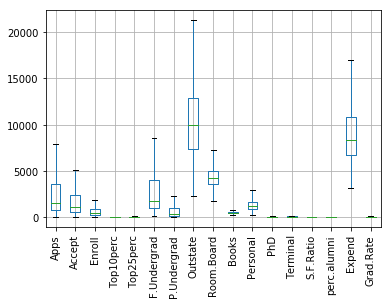

In [183]:
df2_before_scaling_2 = df2_before_scaling
df2_before_scaling_2.boxplot()
plt.xticks(rotation=90)

### Checking dataset for outliers after treating outliers and after scaling

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 <a list of 17 Text xticklabel objects>)

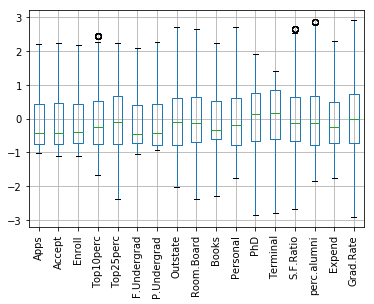

In [184]:
df2_after_scaling_2 = df2_new
df2_after_scaling_2.boxplot()
plt.xticks(rotation=90)

### From the above exercise, we can infer that number of outliers are more after scaling in comparison with before scaling.

### 2.5) Build the covariance matrix, eigenvalues and eigenvector.

### Ans:

### Covariance Matrix, eigenvalues and eigenvectors for the dataset without treating outliers

In [185]:
cov_matrix_1 = np.cov(df2_new_without_treating_outliers.T)
pd.DataFrame(cov_matrix_1)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,1.001289,0.944666,0.847913,0.339270,0.352093,0.815540,0.398777,0.050224,0.165152,0.132729,0.178961,0.391201,0.369968,0.095756,-0.090342,0.259927,0.146944
1,0.944666,1.001289,0.912811,0.192695,0.247795,0.875350,0.441839,-0.025788,0.091016,0.113672,0.201248,0.356216,0.338018,0.176456,-0.160196,0.124878,0.067399
2,0.847913,0.912811,1.001289,0.181527,0.227037,0.965883,0.513730,-0.155678,-0.040284,0.112856,0.281291,0.331896,0.308671,0.237577,-0.181027,0.064252,-0.022370
3,0.339270,0.192695,0.181527,1.001289,0.893144,0.141471,-0.105492,0.563055,0.371959,0.119012,-0.093437,0.532513,0.491768,-0.385370,0.456072,0.661765,0.495627
4,0.352093,0.247795,0.227037,0.893144,1.001289,0.199702,-0.053646,0.490024,0.331917,0.115676,-0.080914,0.546566,0.525425,-0.295009,0.418403,0.528127,0.477896
5,0.815540,0.875350,0.965883,0.141471,0.199702,1.001289,0.571247,-0.216020,-0.068979,0.115699,0.317608,0.318747,0.300406,0.280064,-0.229758,0.018676,-0.078875
6,0.398777,0.441839,0.513730,-0.105492,-0.053646,0.571247,1.001289,-0.253839,-0.061405,0.081304,0.320294,0.149306,0.142086,0.232830,-0.281154,-0.083676,-0.257332
7,0.050224,-0.025788,-0.155678,0.563055,0.490024,-0.216020,-0.253839,1.001289,0.655100,0.038905,-0.299472,0.383476,0.408509,-0.555536,0.566992,0.673646,0.572026
8,0.165152,0.091016,-0.040284,0.371959,0.331917,-0.068979,-0.061405,0.655100,1.001289,0.128128,-0.199685,0.329627,0.375022,-0.363095,0.272714,0.502386,0.425489
9,0.132729,0.113672,0.112856,0.119012,0.115676,0.115699,0.081304,0.038905,0.128128,1.001289,0.179526,0.026940,0.100084,-0.031970,-0.040260,0.112554,0.001062


In [186]:
eig_vals_1, eig_vecs_1 = np.linalg.eig(cov_matrix_1)
print('Eigen Vectors \n%s', eig_vecs_1)
print('\n Eigen Values \n%s', eig_vals_1)

Eigen Vectors 
%s [[-2.48765602e-01  3.31598227e-01  6.30921033e-02 -2.81310530e-01
   5.74140964e-03  1.62374420e-02  4.24863486e-02  1.03090398e-01
   9.02270802e-02 -5.25098025e-02  3.58970400e-01 -4.59139498e-01
   4.30462074e-02 -1.33405806e-01  8.06328039e-02 -5.95830975e-01
   2.40709086e-02]
 [-2.07601502e-01  3.72116750e-01  1.01249056e-01 -2.67817346e-01
   5.57860920e-02 -7.53468452e-03  1.29497196e-02  5.62709623e-02
   1.77864814e-01 -4.11400844e-02 -5.43427250e-01  5.18568789e-01
  -5.84055850e-02  1.45497511e-01  3.34674281e-02 -2.92642398e-01
  -1.45102446e-01]
 [-1.76303592e-01  4.03724252e-01  8.29855709e-02 -1.61826771e-01
  -5.56936353e-02  4.25579803e-02  2.76928937e-02 -5.86623552e-02
   1.28560713e-01 -3.44879147e-02  6.09651110e-01  4.04318439e-01
  -6.93988831e-02 -2.95896092e-02 -8.56967180e-02  4.44638207e-01
   1.11431545e-02]
 [-3.54273947e-01 -8.24118211e-02 -3.50555339e-02  5.15472524e-02
  -3.95434345e-01  5.26927980e-02  1.61332069e-01  1.22678028e-01
 

### Covariance Matrix, eigenvalues and eigenvectors for the dataset with treating outliers

In [187]:
cov_matrix_2 = np.cov(df2_new.T)
pd.DataFrame(cov_matrix_2)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,1.001289,0.956538,0.898039,0.321756,0.364961,0.862111,0.520493,0.065421,0.187717,0.236442,0.230244,0.464522,0.435038,0.126574,-0.101288,0.243248,0.150998
1,0.956538,1.001289,0.936482,0.223586,0.274033,0.898190,0.573429,-0.005009,0.119740,0.208974,0.256676,0.427891,0.403929,0.188749,-0.165729,0.162017,0.079084
2,0.898039,0.936482,1.001289,0.171977,0.230731,0.968549,0.642422,-0.155856,-0.023876,0.202317,0.339785,0.382031,0.354836,0.274622,-0.223010,0.054291,-0.023281
3,0.321756,0.223586,0.171977,1.001289,0.915053,0.111358,-0.180241,0.562884,0.357826,0.153650,-0.116880,0.544749,0.507401,-0.388426,0.456384,0.657886,0.494307
4,0.364961,0.274033,0.230731,0.915053,1.001289,0.181429,-0.099423,0.490200,0.331413,0.169980,-0.086922,0.552172,0.528334,-0.297616,0.417369,0.573643,0.479602
5,0.862111,0.898190,0.968549,0.111358,0.181429,1.001289,0.697027,-0.226457,-0.054546,0.208147,0.360246,0.362030,0.335486,0.324922,-0.285825,0.000371,-0.082345
6,0.520493,0.573429,0.642422,-0.180241,-0.099423,0.697027,1.001289,-0.354673,-0.067725,0.122686,0.344496,0.127827,0.122309,0.371085,-0.419874,-0.202189,-0.265499
7,0.065421,-0.005009,-0.155856,0.562884,0.490200,-0.226457,-0.354673,1.001289,0.656334,0.005117,-0.326029,0.391825,0.413110,-0.574422,0.566465,0.776327,0.573196
8,0.187717,0.119740,-0.023876,0.357826,0.331413,-0.054546,-0.067725,0.656334,1.001289,0.109065,-0.219837,0.341909,0.379759,-0.376915,0.272744,0.581370,0.426339
9,0.236442,0.208974,0.202317,0.153650,0.169980,0.208147,0.122686,0.005117,0.109065,1.001289,0.240172,0.136566,0.159523,-0.008547,-0.042887,0.150177,-0.008061


In [188]:
eig_vals_2, eig_vecs_2 = np.linalg.eig(cov_matrix_2)
print('Eigen Vectors \n%s', eig_vecs_2)
print('\n Eigen Values \n%s', eig_vals_2)

Eigen Vectors 
%s [[-2.62171542e-01  3.14136258e-01  8.10177245e-02 -9.87761685e-02
  -2.19898081e-01  2.18800617e-03 -2.83715076e-02 -8.99498102e-02
   1.30566998e-01 -1.56464458e-01 -8.62132843e-02  1.82169814e-01
  -5.99137640e-01  8.99775288e-02  8.88697944e-02  5.49428396e-01
   5.41453698e-03]
 [-2.30562461e-01  3.44623583e-01  1.07658626e-01 -1.18140437e-01
  -1.89634940e-01 -1.65212882e-02 -1.29584896e-02 -1.37606312e-01
   1.42275847e-01 -1.49209799e-01 -4.25899061e-02 -3.91041719e-01
   6.61496927e-01  1.58861886e-01  4.37945938e-02  2.91572312e-01
   1.44582845e-02]
 [-1.89276397e-01  3.82813322e-01  8.55296892e-02 -9.30717094e-03
  -1.62314818e-01 -6.80794143e-02 -1.52403625e-02 -1.44216938e-01
   5.08712481e-02 -6.48997860e-02 -4.38408622e-02  7.16684935e-01
   2.33235272e-01 -3.53988202e-02 -6.19241658e-02 -4.17001280e-01
  -4.97908902e-02]
 [-3.38874521e-01 -9.93191661e-02 -7.88293849e-02  3.69115031e-01
  -1.57211016e-01 -8.88656824e-02 -2.57455284e-01  2.89538833e-01
 

### 2.6) Write the explicit form of the first PC (in terms of Eigen Vectors).

### Ans:

### First PC for dataset without treating outliers:

### Eqn1 => -2.48765602e-01*Apps + 3.31598227e-01*Accept + 6.30921033e-02*Enroll + -2.81310530e-01*Top10perc + 5.74140964e-03*Top25perc + 1.62374420e-02*F.Undergrad + 4.24863486e-02*P.Undergrad + 1.03090398e-01*Outstate + 9.02270802e-02*Room.Board + -5.25098025e-02*Books + 3.58970400e-01*Personal + -4.59139498e-01*PhD + 4.30462074e-02*Terminal + -1.33405806e-01*S.F.Ratio + 8.06328039e-02*perc.alumni + -5.95830975e-01*Expend + 2.40709086e-02*Grad.Rate

### First PC for dataset with treating outliers:

### Eqn2 => -2.62171542e-01*Apps + 3.14136258e-01*Accept + 8.10177245e-02*Enroll + -9.87761685e-02*Top10perc + -2.19898081e-01*Top25perc + 2.18800617e-03*F.Undergrad + -2.83715076e-02*P.Undergrad + -8.99498102e-02*Outstate + 1.30566998e-01*Room.Board + -1.56464458e-01*Books + -8.62132843e-02*Personal + 1.82169814e-01*PhD + -5.99137640e-01*Terminal + 8.99775288e-02*S.F.Ratio + 8.88697944e-02*perc.alumni + 5.49428396e-01*Expend + 5.41453698e-03*Grad.Rate

### 2.7) Discuss the cumulative values of the eigenvalues. How does it help you to decide on the optimum number of principal components? What do the eigenvectors indicate?
### Perform PCA and export the data of the Principal Component scores into a data frame.

### Ans:

### Cumulative values of the eigenvalues on dataset without treating outliers:

In [189]:
tot_1 = sum(eig_vals_1)
var_exp_1 = [( i /tot_1 ) * 100 for i in sorted(eig_vals_1, reverse=True)]
cum_var_exp_1 = np.cumsum(var_exp_1)
print("Cumulative Variance Explained", cum_var_exp_1)

Cumulative Variance Explained [ 32.0206282   58.36084263  65.26175919  71.18474841  76.67315352
  81.65785448  85.21672597  88.67034731  91.78758099  94.16277251
  96.00419883  97.30024023  98.28599436  99.13183669  99.64896227
  99.86471628 100.        ]


In [203]:
cum_values_eigen_values_1 = np.cumsum(eig_vals_1)
cum_values_eigen_values_1

array([ 5.45052162,  9.93412848, 11.1087961 , 12.11700183, 13.05123305,
       13.89972422, 14.50551203, 15.09338425, 15.62399687, 16.02829977,
       16.05132764, 16.08805309, 16.40149897, 16.4895236 , 16.6335021 ,
       16.80129625, 17.02190722])

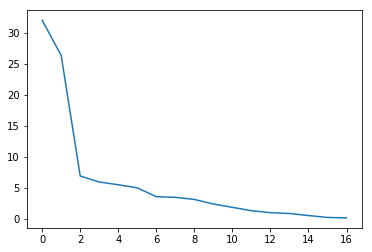

In [190]:
plt.plot(var_exp_1)

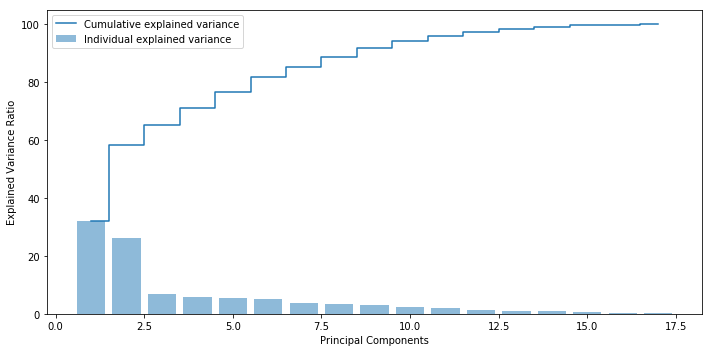

In [191]:
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals_1.size + 1), var_exp_1, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals_1.size + 1), cum_var_exp_1, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [192]:
from sklearn.decomposition import PCA

# NOTE - we are generating only 4 PCA dimensions (dimensionality reduction from 9 to 7)

pca_1 = PCA(n_components=4)
data_reduced_1 = pca_1.fit_transform(df2_new_without_treating_outliers)
data_reduced_1.transpose()

array([[-1.59285540e+00, -2.19240180e+00, -1.43096371e+00, ...,
        -7.32560597e-01,  7.91932736e+00, -4.69508069e-01],
       [ 7.67333511e-01, -5.78829984e-01, -1.09281889e+00, ...,
        -7.72352371e-02, -2.06832886e+00,  3.66660946e-01],
       [-1.01073639e-01,  2.27879749e+00, -4.38092673e-01, ...,
        -4.06235354e-04,  2.07356284e+00, -1.32891496e+00],
       [-9.21749978e-01,  3.58892376e+00,  6.77239076e-01, ...,
         5.43183974e-02,  8.52067155e-01, -1.08026322e-01]])

In [193]:
pca_1.components_

array([[ 0.2487656 ,  0.2076015 ,  0.17630359,  0.35427395,  0.34400128,
         0.15464096,  0.0264425 ,  0.29473642,  0.24903045,  0.06475752,
        -0.04252854,  0.31831287,  0.31705602, -0.17695789,  0.20508237,
         0.31890875,  0.25231565],
       [ 0.33159823,  0.37211675,  0.40372425, -0.08241182, -0.04477865,
         0.41767377,  0.31508783, -0.24964352, -0.13780888,  0.05634184,
         0.21992922,  0.05831132,  0.04642945,  0.24666528, -0.24659527,
        -0.13168986, -0.16924053],
       [-0.06309212, -0.10124904, -0.0829856 ,  0.03505534, -0.02414777,
        -0.06139295,  0.13968171,  0.04659887,  0.14896738,  0.67741165,
         0.49972112, -0.12702836, -0.06603757, -0.2898484 , -0.14698927,
         0.22674404, -0.20806465],
       [ 0.28131094,  0.26781686,  0.16182687, -0.05154511, -0.10976846,
         0.10041241, -0.15855843,  0.13129148,  0.18499603,  0.08708922,
        -0.23071059, -0.53472489, -0.51944281, -0.16118957,  0.01731421,
         0.07927278

In [194]:
df_comp_1 = pd.DataFrame(pca_1.components_,columns=list(df2_new_without_treating_outliers))
df_comp_1.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,0.248766,0.207602,0.176304,0.354274,0.344001,0.154641,0.026443,0.294736,0.249030,0.064758,-0.042529,0.318313,0.317056,-0.176958,0.205082,0.318909,0.252316
1,0.331598,0.372117,0.403724,-0.082412,-0.044779,0.417674,0.315088,-0.249644,-0.137809,0.056342,0.219929,0.058311,0.046429,0.246665,-0.246595,-0.131690,-0.169241
2,-0.063092,-0.101249,-0.082986,0.035055,-0.024148,-0.061393,0.139682,0.046599,0.148967,0.677412,0.499721,-0.127028,-0.066038,-0.289848,-0.146989,0.226744,-0.208065
3,0.281311,0.267817,0.161827,-0.051545,-0.109768,0.100412,-0.158558,0.131291,0.184996,0.087089,-0.230711,-0.534725,-0.519443,-0.161190,0.017314,0.079273,0.269129


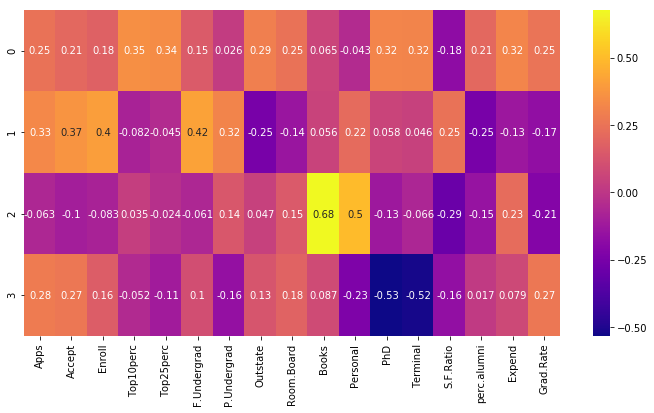

In [195]:
plt.figure(figsize=(12,6))
sns.heatmap(df_comp_1,cmap='plasma', annot = True)

### The cumulative values of the eigenvalues are : 5.45052162 9.93412848 11.10879609 12.11700182 13.05123305 13.89972422 14.50551202  15.09338424 15.62399686 16.02829976  16.05132763 16.08805308 16.40149896 16.4895236 16.6335021  16.80129625 17.02190721
### The cumulative variance for the eigenvalues are as follows: 32.0206282, 58.36084263, 65.26175919, 71.18474841, 76.67315352, 81.65785448, 85.21672597, 88.67034731, 91.78758099, 94.16277251, 96.00419883, 97.30024023, 98.28599436, 99.13183669, 99.64896227, 99.86471628, 100.
### As we can see from the eigen values, there are 4 values which are greater than 1. So the corresponding cumulative variance explained by each of the components are : 32.0206282, 26.3402144, 6.90091656, 5.92298922. And the total variance captured by the first 4 components is 71.18474841.
### Eigenvectors indicate the direction of principal component.

### Cumulative values of the eigenvalues on dataset with treating outliers:

In [196]:
tot_2 = sum(eig_vals_2)
var_exp_2= [( i /tot_2 ) * 100 for i in sorted(eig_vals_2, reverse=True)]
cum_var_exp_2 = np.cumsum(var_exp_2)
print("Cumulative Variance Explained", cum_var_exp_2)

Cumulative Variance Explained [ 33.26608367  62.02142867  68.63859223  74.53673619  79.66062886
  84.15926753  87.59551019  90.79435736  93.28246491  95.52086136
  96.97201814  97.83716159  98.62640821  99.20703552  99.64582321
  99.86844192 100.        ]


In [204]:
cum_values_eigen_values_2 = np.cumsum(eig_vals_2)
cum_values_eigen_values_2

array([ 5.6625219 , 10.55723004, 11.68359748, 12.68757408, 13.55975833,
       14.32551243, 14.91042647, 15.45493127, 15.87845463, 16.25947239,
       16.50648695, 16.52888065, 16.5667746 , 16.71403851, 16.84838334,
       16.94721718, 17.02190722])

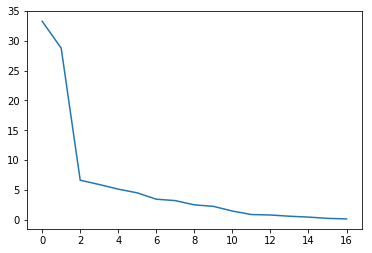

In [197]:
plt.plot(var_exp_2)

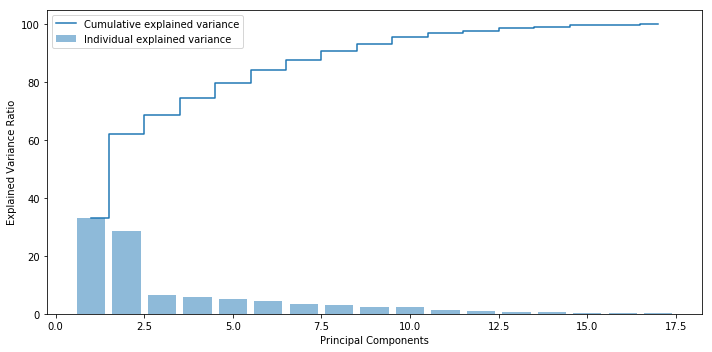

In [198]:
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eig_vals_2.size + 1), var_exp_2, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eig_vals_2.size + 1), cum_var_exp_2, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

In [199]:
from sklearn.decomposition import PCA

# NOTE - we are generating only 4 PCA dimensions (dimensionality reduction from 9 to 7)

pca_2 = PCA(n_components=4)
data_reduced_2 = pca_2.fit_transform(df2_new)
data_reduced_2.transpose()

array([[-1.60249935, -1.80467541, -1.60828259, ..., -0.57688265,
         6.57095202, -0.47739311],
       [ 0.99368302, -0.07041498, -1.38279213, ...,  0.01779847,
        -1.18493013,  1.0439467 ],
       [ 0.03004368,  2.12212669, -0.5015117 , ...,  0.32216026,
         1.32596169, -1.42543591],
       [-1.00842187,  3.13894111, -0.03637386, ..., -0.58725913,
         0.07771048, -1.30027482]])

In [200]:
pca_2.components_

array([[ 0.26217154,  0.23056246,  0.1892764 ,  0.33887452,  0.33469053,
         0.16329301,  0.02247971,  0.28354728,  0.24418659,  0.09670828,
        -0.03522996,  0.32641069,  0.32311598, -0.16315164,  0.18661083,
         0.32895585,  0.23882245],
       [ 0.31413626,  0.34462358,  0.38281332, -0.09931917, -0.0595055 ,
         0.39863637,  0.35755005, -0.25186362, -0.13190912,  0.09397395,
         0.23243959,  0.05513902,  0.04303321,  0.25980456, -0.25709255,
        -0.16000895, -0.16752366],
       [-0.08101755, -0.10765838, -0.08552986,  0.0788293 ,  0.05079392,
        -0.07370809, -0.04035679, -0.01493937,  0.02113784,  0.69712114,
         0.53097282, -0.0811132 , -0.05897875, -0.27415069, -0.10371589,
         0.18420556, -0.2453359 ],
       [ 0.09877612,  0.11814027,  0.00930725, -0.369115  , -0.41682441,
         0.01395061,  0.22535104,  0.26297533,  0.58089417, -0.0361563 ,
        -0.11498298, -0.14726099, -0.08900791, -0.25948611, -0.22398247,
         0.2137562 

In [201]:
df_comp_2 = pd.DataFrame(pca_2.components_,columns=list(df2_new))
df_comp_2.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,0.262172,0.230562,0.189276,0.338875,0.334691,0.163293,0.022480,0.283547,0.244187,0.096708,-0.035230,0.326411,0.323116,-0.163152,0.186611,0.328956,0.238822
1,0.314136,0.344624,0.382813,-0.099319,-0.059506,0.398636,0.357550,-0.251864,-0.131909,0.093974,0.232440,0.055139,0.043033,0.259805,-0.257093,-0.160009,-0.167524
2,-0.081018,-0.107658,-0.085530,0.078829,0.050794,-0.073708,-0.040357,-0.014939,0.021138,0.697121,0.530973,-0.081113,-0.058979,-0.274151,-0.103716,0.184206,-0.245336
3,0.098776,0.118140,0.009307,-0.369115,-0.416824,0.013951,0.225351,0.262975,0.580894,-0.036156,-0.114983,-0.147261,-0.089008,-0.259486,-0.223982,0.213756,-0.036191


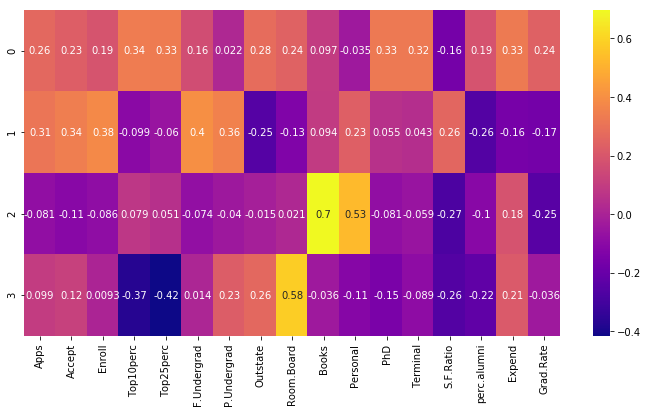

In [202]:
plt.figure(figsize=(12,6))
sns.heatmap(df_comp_2,cmap='plasma', annot=True)

### The cumulative values of the eigenvalues are : 5.6625219 10.55723005 11.68359749 12.68757408 13.55975834 14.32551244 14.91042648 15.45493128 16.301978 16.68299577 16.93001033 16.97479771 17.01269166 17.15995558 17.29430041 17.39313425 17.46782428.
### The cumulative variance for the eigenvalues are as follows: 33.26608367  62.02142867  68.63859223  74.53673619  79.66062886 84.15926753  87.59551019  90.79435736  93.28246491  95.52086136 96.97201814  97.83716159  98.62640821  99.20703552  99.64582321 99.86844192 100.
### As we can see from the eigen values, there are 4 values which are greater than 1. So the corresponding cumulative variance explained by each of the components are : 33.26608367  62.02142867  68.63859223  74.53673619. And the total variance captured by the first 4 components is 74.53673619.
### Eigenvectors indicate the direction of principal component.

### 2.8) Mention the business implication of using the Principal Component Analysis for this case study.

### Ans:

### 1) Principal component analysis (PCA) is a technique for reducing the dimensionality of such datasets, increasing interpretability but at the same time minimizing information loss. 
### 2) It does so by creating new uncorrelated variables that successively maximize variance. 
### 3) In this case study, we initially had 18 variables and after performing PCA we have reduced to 4 Principal components, thereby successfully acheiving dimensional reduction.
### 4) The 4 Principal components have captured more than 70% of the variance, thereby capturing maximum variance. 
### 5) The first principal component captures the maximum variability in the data. The remaining part of the data which is not captured by PC1 is called as noise. This noise will be the feeding signal for the second principal component and so on.